# Previsão do Nível de Depressão e Ansiedade em Idosos — Benchmark de Modelos Tradicionais

## Objetivo

Este notebook tem como objetivo responder à seguinte questão de investigação:

> **Conseguimos prever o nível de depressão e ansiedade em idosos a partir de variáveis de estilo de vida e sociodemográficas, nomeadamente dados de atividade física?**

Para tal, treinamos modelos de classificação para prever:
- **PHQ-9** — nível de depressão (5 classes clínicas)
- **GAD-7** — nível de ansiedade (4 classes clínicas)

As variáveis `phq9_total` e `gad7_total` são **excluídas do treino**, o modelo só tem acesso a variáveis de estilo de vida e sociodemográficas.

## Dataset

- **Ficheiro:** `Dataset_Idosos.xlsx`
- **Dimensão:** 3915 participantes × 17 variáveis
- **Natureza:** Dataset sintético gerado para fins académicos, os padrões presentes podem não reflectir a complexidade e variabilidade de uma população real de idosos
- **Features de treino:** idade, género, educação, rendimento, estado civil, situação de vida, comorbilidades, atividade física (dias, minutos por sessão, tipo, intensidade), horas de sono

## Classificações Clínicas Oficiais

**PHQ-9 (Depressão):**
| Score | Classificação |
|---|---|
| 0–4 | Mínima |
| 5–9 | Leve |
| 10–14 | Moderada |
| 15–19 | Moderadamente grave |
| 20–27 | Grave |

**GAD-7 (Ansiedade):**
| Score | Classificação |
|---|---|
| 0–4 | Mínima |
| 5–9 | Leve |
| 10–14 | Moderada |
| 15–21 | Grave |

## Estratégia de Validação

A abordagem utilizada foi:

- **80% treino / 20% teste** (holdout final)
- **Cross-validation com 5 folds** no conjunto de treino, para seleção e avaliação de hiperparâmetros

---
## 1. Importações e Configuração

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.inspection import permutation_importance

# Modelos de classificação
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

# Métricas
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

SEED = 42
np.random.seed(SEED)
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ Dependências carregadas com sucesso.')

✅ Dependências carregadas com sucesso.


---
## 2. Carregamento e Preparação dos Dados

In [3]:
df = pd.read_csv('/content/drive/MyDrive/IACD/Projeto/notebooks/Dataset_Idosos.csv', sep=';')
print(f'Dimensão original: {df.shape[0]} linhas × {df.shape[1]} colunas')
df.head()

Dimensão original: 3915 linhas × 16 colunas


,participant_id,age,gender,education_years,monthly_income,marital_status,living_situation,comorbidities_count,physical_activity_days_per_week,physical_activity_minutes_per_session,physical_activity_total_minutes_week,physical_activity_type,physical_activity_intensity,sleep_hours,phq9_total,gad7_total
0,1,65,1,3,950.15,1,1,1.0,7.0,52.0,364.0,1.0,2.0,7.9,0.0,0.0
1,2,71,1,6,1600.25,1,1,2.0,5.0,37.0,185.0,1.0,2.0,7.2,1.0,1.0
2,3,68,2,7,1800.10,2,2,2.0,6.0,43.0,258.0,1.0,2.0,7.4,2.0,2.0
3,4,70,2,5,1350.35,1,1,2.0,5.0,35.0,175.0,1.0,2.0,7.0,1.0,1.0
4,5,68,1,14,4500.20,2,2,2.0,7.0,45.0,315.0,5.0,3.0,7.6,2.0,2.0


In [4]:
# Criar variáveis target com classificações clínicas oficiais

# PHQ-9: 5 classes
bins_phq9   = [-1, 4, 9, 14, 19, 27]
labels_phq9 = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
df['phq9_classe'] = pd.cut(df['phq9_total'], bins=bins_phq9, labels=labels_phq9)

# GAD-7: 4 classes
bins_gad7   = [-1, 4, 9, 14, 21]
labels_gad7 = ['Mínima', 'Leve', 'Moderada', 'Grave']
df['gad7_classe'] = pd.cut(df['gad7_total'], bins=bins_gad7, labels=labels_gad7)

print('Distribuição PHQ-9:')
print(df['phq9_classe'].value_counts().sort_index())
print()
print('Distribuição GAD-7:')
print(df['gad7_classe'].value_counts().sort_index())

Distribuição PHQ-9:
phq9_classe
Mínima        1648
Leve          1040
Moderada       555
Mod. grave     405
Grave          267
Name: count, dtype: int64

Distribuição GAD-7:
gad7_classe
Mínima      2185
Leve         901
Moderada     544
Grave        285
Name: count, dtype: int64


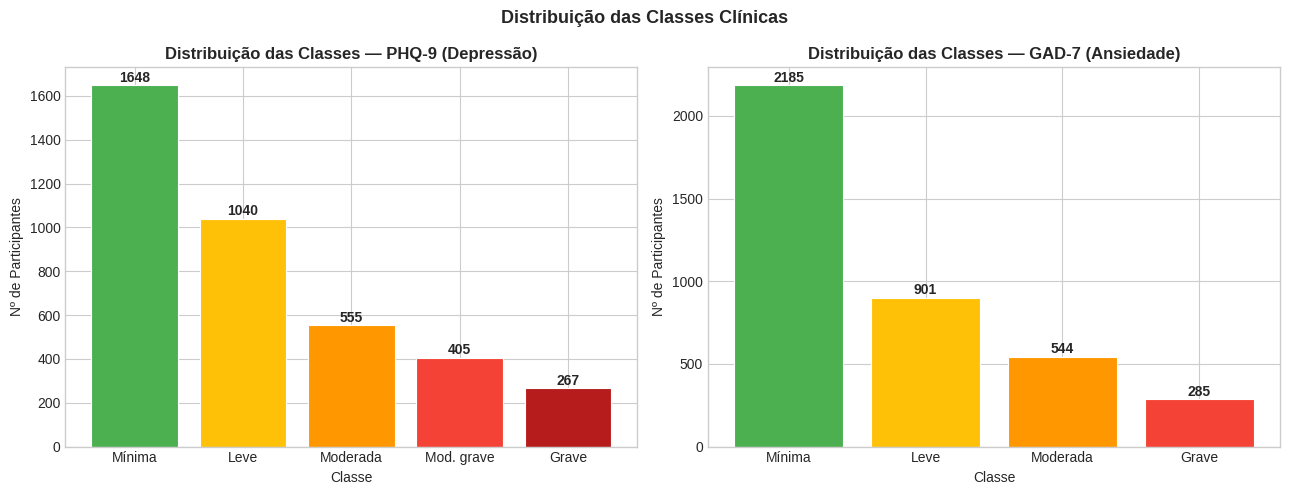

In [5]:
# Visualização da distribuição das classes
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# PHQ-9
counts_phq9 = df['phq9_classe'].value_counts().sort_index()
colors_phq9 = ['#4CAF50', '#FFC107', '#FF9800', '#F44336', '#B71C1C']
bars = axes[0].bar(counts_phq9.index, counts_phq9.values,
                   color=colors_phq9, edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribuição das Classes — PHQ-9 (Depressão)', fontweight='bold')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Nº de Participantes')
for bar, val in zip(bars, counts_phq9.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')

# GAD-7
counts_gad7 = df['gad7_classe'].value_counts().sort_index()
colors_gad7 = ['#4CAF50', '#FFC107', '#FF9800', '#F44336']
bars = axes[1].bar(counts_gad7.index, counts_gad7.values,
                   color=colors_gad7, edgecolor='white', linewidth=0.8)
axes[1].set_title('Distribuição das Classes — GAD-7 (Ansiedade)', fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nº de Participantes')
for bar, val in zip(bars, counts_gad7.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(val), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Distribuição das Classes Clínicas', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [6]:
# Definir features de treino — excluir IDs, scores clínicos
EXCLUDE = ['participant_id', 'phq9_total', 'gad7_total', 'phq9_classe', 'gad7_classe']

FEATURES = [c for c in df.columns if c not in EXCLUDE]
print('Features de treino:')
print(FEATURES)

Features de treino:
['age', 'gender', 'education_years', 'monthly_income', 'marital_status', 'living_situation', 'comorbidities_count', 'physical_activity_days_per_week', 'physical_activity_minutes_per_session', 'physical_activity_total_minutes_week', 'physical_activity_type', 'physical_activity_intensity', 'sleep_hours']


---
## 3. Análise Exploratória — Features vs. Targets

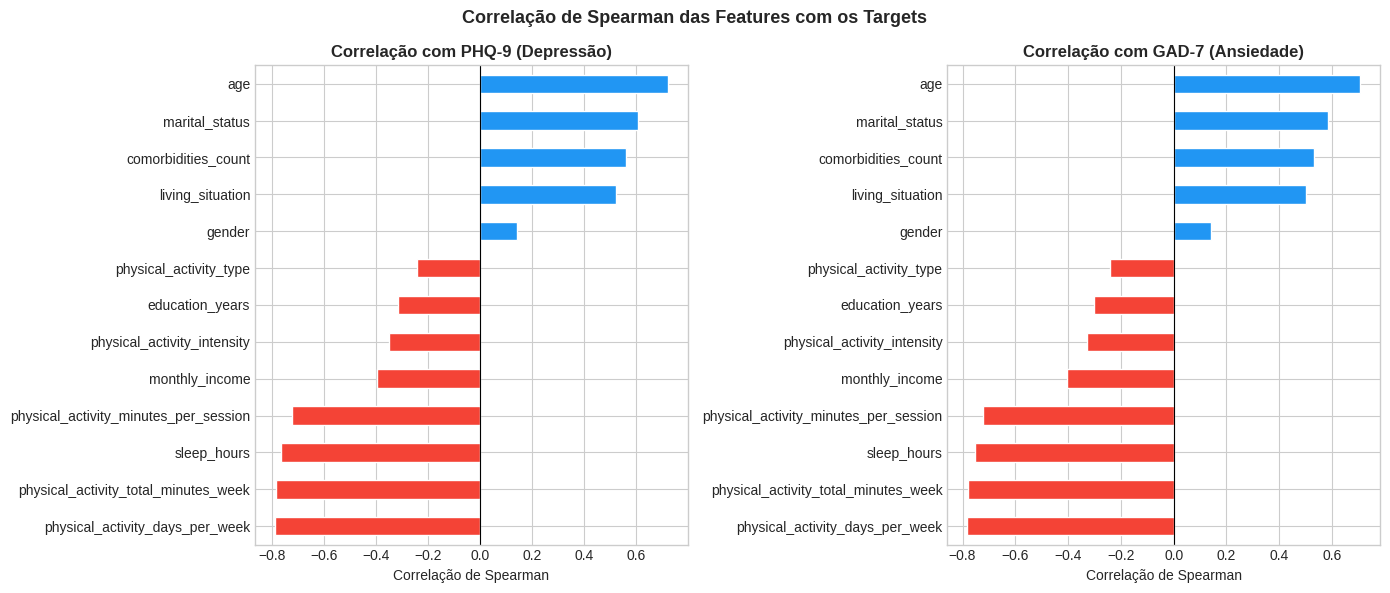

In [7]:
# Correlação das features numéricas com os scores contínuos (para contexto)
# Spearman é mais adequado que Pearson pois não assume linearidade
# e é robusto a variáveis ordinais e outliers
numeric_features = df[FEATURES].select_dtypes(include='number').columns.tolist()

corr_phq9 = df[numeric_features + ['phq9_total']].corr(method='spearman')['phq9_total'].drop('phq9_total').sort_values()
corr_gad7 = df[numeric_features + ['gad7_total']].corr(method='spearman')['gad7_total'].drop('gad7_total').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, corr, title in zip(axes,
                            [corr_phq9, corr_gad7],
                            ['Correlação com PHQ-9 (Depressão)', 'Correlação com GAD-7 (Ansiedade)']):
    colors = ['#F44336' if c < 0 else '#2196F3' for c in corr]
    corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Correlação de Spearman')

plt.suptitle('Correlação de Spearman das Features com os Targets',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Pré-processamento e Split

In [8]:
# Preparar X e os dois targets
df_model = df.dropna(subset=['phq9_classe', 'gad7_classe']).copy()
print(f'Amostras após remover nulos nos targets: {len(df_model)}')

X = df_model[FEATURES]
y_phq9 = df_model['phq9_classe'].astype(str)
y_gad7 = df_model['gad7_classe'].astype(str)

print(f'\nFeatures: {X.shape[1]}')
print(f'Nulos em X: {X.isnull().sum().sum()}')

Amostras após remover nulos nos targets: 3915

Features: 13
Nulos em X: 0


In [9]:
# Split 80/20 — PHQ-9
X_train_phq9, X_test_phq9, y_train_phq9, y_test_phq9 = train_test_split(
    X, y_phq9, test_size=0.20, random_state=SEED, stratify=y_phq9
)

# Split 80/20 — GAD-7
X_train_gad7, X_test_gad7, y_train_gad7, y_test_gad7 = train_test_split(
    X, y_gad7, test_size=0.20, random_state=SEED, stratify=y_gad7
)

print('PHQ-9:')
print(f'  Treino:  {len(X_train_phq9)} amostras | Teste: {len(X_test_phq9)} amostras')
print('GAD-7:')
print(f'  Treino:  {len(X_train_gad7)} amostras | Teste: {len(X_test_gad7)} amostras')
print()
print('Nota: stratify=y garante que a proporção de classes é mantida no split.')

PHQ-9:
  Treino:  3132 amostras | Teste: 783 amostras
GAD-7:
  Treino:  3132 amostras | Teste: 783 amostras

Nota: stratify=y garante que a proporção de classes é mantida no split.


In [10]:
# Pipeline base: imputação da mediana + standardização
# A imputação ocorre dentro do pipeline para evitar data leakage
def make_pipeline(model):
    """Cria um pipeline com imputação de mediana, standardização e o modelo."""
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
print('✅ Pipeline e CV configurados.')

✅ Pipeline e CV configurados.


---
## 5. Treino e Avaliação dos Modelos

Para cada modelo e cada target (PHQ-9 e GAD-7):
1. **5-fold cross-validation** no conjunto de treino
2. Treino no conjunto de treino completo
3. Avaliação no **conjunto de teste holdout**

**Métricas utilizadas:**
- **Accuracy** — proporção de classificações corretas
- **F1-Score macro** — média do F1 por classe, sem ponderação pela frequência (adequado para classes desequilibradas)
- **F1-Score weighted** — média do F1 ponderada pela frequência de cada classe

In [11]:
def evaluate_classifier(name, pipeline, X_train, y_train, X_test, y_test, cv):
    """
    Avalia um classificador com cross-validation e no conjunto de teste.
    Retorna um dicionário com as métricas.
    """
    # Cross-validation no treino
    cv_acc  = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
    cv_f1   = cross_val_score(pipeline, X_train, y_train, cv=cv,
                               scoring='f1_macro')

    # Treino final e avaliação no teste
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    test_acc     = accuracy_score(y_test, y_pred)
    test_f1_mac  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    test_f1_wgt  = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    return {
        'Modelo': name,
        'CV Accuracy (média)': cv_acc.mean(),
        'CV Accuracy (std)': cv_acc.std(),
        'CV F1 Macro (média)': cv_f1.mean(),
        'CV F1 Macro (std)': cv_f1.std(),
        'Teste Accuracy': test_acc,
        'Teste F1 Macro': test_f1_mac,
        'Teste F1 Weighted': test_f1_wgt,
        'y_pred': y_pred
    }

print('✅ Função de avaliação definida.')

✅ Função de avaliação definida.


In [12]:
# Definição dos modelos
models = {
    'Regressão Logística':  LogisticRegression(max_iter=1000, random_state=SEED),
    'Ridge Classifier':     RidgeClassifier(),
    'Naive Bayes':          GaussianNB(),
    'KNN':                  KNeighborsClassifier(n_neighbors=7),
    'Árvore de Decisão':    DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                    random_state=SEED),
    'SVM (RBF)':            SVC(kernel='rbf', C=1.0, random_state=SEED),
    'Random Forest':        RandomForestClassifier(n_estimators=200, max_depth=6,
                                                   min_samples_leaf=5, random_state=SEED,
                                                   n_jobs=-1),
    'Extra Trees':          ExtraTreesClassifier(n_estimators=200, max_depth=6,
                                                 min_samples_leaf=5, random_state=SEED,
                                                 n_jobs=-1),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, max_depth=3,
                                                        learning_rate=0.05, subsample=0.8,
                                                        random_state=SEED),
    'MLP':                  MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu',
                                          alpha=0.01, max_iter=500, random_state=SEED,
                                          early_stopping=False),
}

print(f'Total de modelos: {len(models)}')

Total de modelos: 10


### 5.1 Treino — PHQ-9 (Depressão)

In [13]:
results_phq9 = []
predictions_phq9 = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    r = evaluate_classifier(name, pipe, X_train_phq9, y_train_phq9,
                             X_test_phq9, y_test_phq9, CV)
    predictions_phq9[name] = r.pop('y_pred')
    results_phq9.append(r)
    print(f"{name:<25} | CV Acc: {r['CV Accuracy (média)']:.4f} ± {r['CV Accuracy (std)']:.4f} "
          f"| Teste Acc: {r['Teste Accuracy']:.4f} | Teste F1 Macro: {r['Teste F1 Macro']:.4f}")

Regressão Logística       | CV Acc: 0.6954 ± 0.0095 | Teste Acc: 0.6769 | Teste F1 Macro: 0.6858
Ridge Classifier          | CV Acc: 0.6622 ± 0.0145 | Teste Acc: 0.6590 | Teste F1 Macro: 0.6471
Naive Bayes               | CV Acc: 0.6181 ± 0.0081 | Teste Acc: 0.6041 | Teste F1 Macro: 0.5613
KNN                       | CV Acc: 0.7334 ± 0.0093 | Teste Acc: 0.7535 | Teste F1 Macro: 0.7332
Árvore de Decisão         | CV Acc: 0.6820 ± 0.0184 | Teste Acc: 0.6616 | Teste F1 Macro: 0.6782
SVM (RBF)                 | CV Acc: 0.7567 ± 0.0138 | Teste Acc: 0.7586 | Teste F1 Macro: 0.7455
Random Forest             | CV Acc: 0.7232 ± 0.0196 | Teste Acc: 0.7241 | Teste F1 Macro: 0.7170
Extra Trees               | CV Acc: 0.7002 ± 0.0131 | Teste Acc: 0.6948 | Teste F1 Macro: 0.6755
Gradient Boosting         | CV Acc: 0.7672 ± 0.0112 | Teste Acc: 0.7791 | Teste F1 Macro: 0.7658
MLP                       | CV Acc: 0.7564 ± 0.0071 | Teste Acc: 0.7612 | Teste F1 Macro: 0.7514


### 5.2 Treino — GAD-7 (Ansiedade)

In [14]:
results_gad7 = []
predictions_gad7 = {}

for name, model in models.items():
    pipe = make_pipeline(model)
    r = evaluate_classifier(name, pipe, X_train_gad7, y_train_gad7,
                             X_test_gad7, y_test_gad7, CV)
    predictions_gad7[name] = r.pop('y_pred')
    results_gad7.append(r)
    print(f"{name:<25} | CV Acc: {r['CV Accuracy (média)']:.4f} ± {r['CV Accuracy (std)']:.4f} "
          f"| Teste Acc: {r['Teste Accuracy']:.4f} | Teste F1 Macro: {r['Teste F1 Macro']:.4f}")

Regressão Logística       | CV Acc: 0.7554 ± 0.0121 | Teste Acc: 0.7433 | Teste F1 Macro: 0.6803
Ridge Classifier          | CV Acc: 0.7337 ± 0.0116 | Teste Acc: 0.7356 | Teste F1 Macro: 0.6644
Naive Bayes               | CV Acc: 0.6817 ± 0.0034 | Teste Acc: 0.6692 | Teste F1 Macro: 0.5521
KNN                       | CV Acc: 0.7749 ± 0.0088 | Teste Acc: 0.7676 | Teste F1 Macro: 0.7114
Árvore de Decisão         | CV Acc: 0.7522 ± 0.0106 | Teste Acc: 0.7344 | Teste F1 Macro: 0.6707
SVM (RBF)                 | CV Acc: 0.7717 ± 0.0152 | Teste Acc: 0.7663 | Teste F1 Macro: 0.7171
Random Forest             | CV Acc: 0.7739 ± 0.0085 | Teste Acc: 0.7510 | Teste F1 Macro: 0.6956
Extra Trees               | CV Acc: 0.7500 ± 0.0174 | Teste Acc: 0.7446 | Teste F1 Macro: 0.6675
Gradient Boosting         | CV Acc: 0.7880 ± 0.0138 | Teste Acc: 0.7791 | Teste F1 Macro: 0.7283
MLP                       | CV Acc: 0.7810 ± 0.0093 | Teste Acc: 0.7701 | Teste F1 Macro: 0.7158


---
## 6. Comparação dos Resultados

In [15]:
# Tabelas de resultados
results_phq9_df = pd.DataFrame(results_phq9).set_index('Modelo')\
    .sort_values('Teste F1 Macro', ascending=False)
results_gad7_df = pd.DataFrame(results_gad7).set_index('Modelo')\
    .sort_values('Teste F1 Macro', ascending=False)

cols = ['CV Accuracy (média)', 'CV Accuracy (std)', 'CV F1 Macro (média)',
        'Teste Accuracy', 'Teste F1 Macro', 'Teste F1 Weighted']

print('PHQ-9 — Depressão')
display(results_phq9_df[cols].round(4).style
    .background_gradient(subset=['Teste F1 Macro'], cmap='RdYlGn')
    .background_gradient(subset=['Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('Resultados PHQ-9 — ordenado por Teste F1 Macro (descendente)'))

print()
print('GAD-7 — Ansiedade')
display(results_gad7_df[cols].round(4).style
    .background_gradient(subset=['Teste F1 Macro'], cmap='RdYlGn')
    .background_gradient(subset=['Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('Resultados GAD-7 — ordenado por Teste F1 Macro (descendente)'))

PHQ-9 — Depressão


,CV Accuracy (média),CV Accuracy (std),CV F1 Macro (média),Teste Accuracy,Teste F1 Macro,Teste F1 Weighted
Modelo,,,,,,
Gradient Boosting,0.7672,0.0112,0.7557,0.7791,0.7658,0.7795
MLP,0.7564,0.0071,0.7455,0.7612,0.7514,0.7622
SVM (RBF),0.7567,0.0138,0.7492,0.7586,0.7455,0.7592
KNN,0.7334,0.0093,0.7201,0.7535,0.7332,0.7548
Random Forest,0.7232,0.0196,0.7135,0.7241,0.7170,0.7216
Regressão Logística,0.6954,0.0095,0.6943,0.6769,0.6858,0.6749
Árvore de Decisão,0.6820,0.0184,0.6843,0.6616,0.6782,0.6680
Extra Trees,0.7002,0.0131,0.6850,0.6948,0.6755,0.6829
Ridge Classifier,0.6622,0.0145,0.6333,0.6590,0.6471,0.6449



GAD-7 — Ansiedade


,CV Accuracy (média),CV Accuracy (std),CV F1 Macro (média),Teste Accuracy,Teste F1 Macro,Teste F1 Weighted
Modelo,,,,,,
Gradient Boosting,0.7880,0.0138,0.7323,0.7791,0.7283,0.7752
SVM (RBF),0.7717,0.0152,0.7137,0.7663,0.7171,0.7623
MLP,0.7810,0.0093,0.7201,0.7701,0.7158,0.7697
KNN,0.7749,0.0088,0.7158,0.7676,0.7114,0.7653
Random Forest,0.7739,0.0085,0.7067,0.7510,0.6956,0.7422
Regressão Logística,0.7554,0.0121,0.7013,0.7433,0.6803,0.7343
Árvore de Decisão,0.7522,0.0106,0.6897,0.7344,0.6707,0.7233
Extra Trees,0.7500,0.0174,0.6704,0.7446,0.6675,0.7261
Ridge Classifier,0.7337,0.0116,0.6510,0.7356,0.6644,0.7219


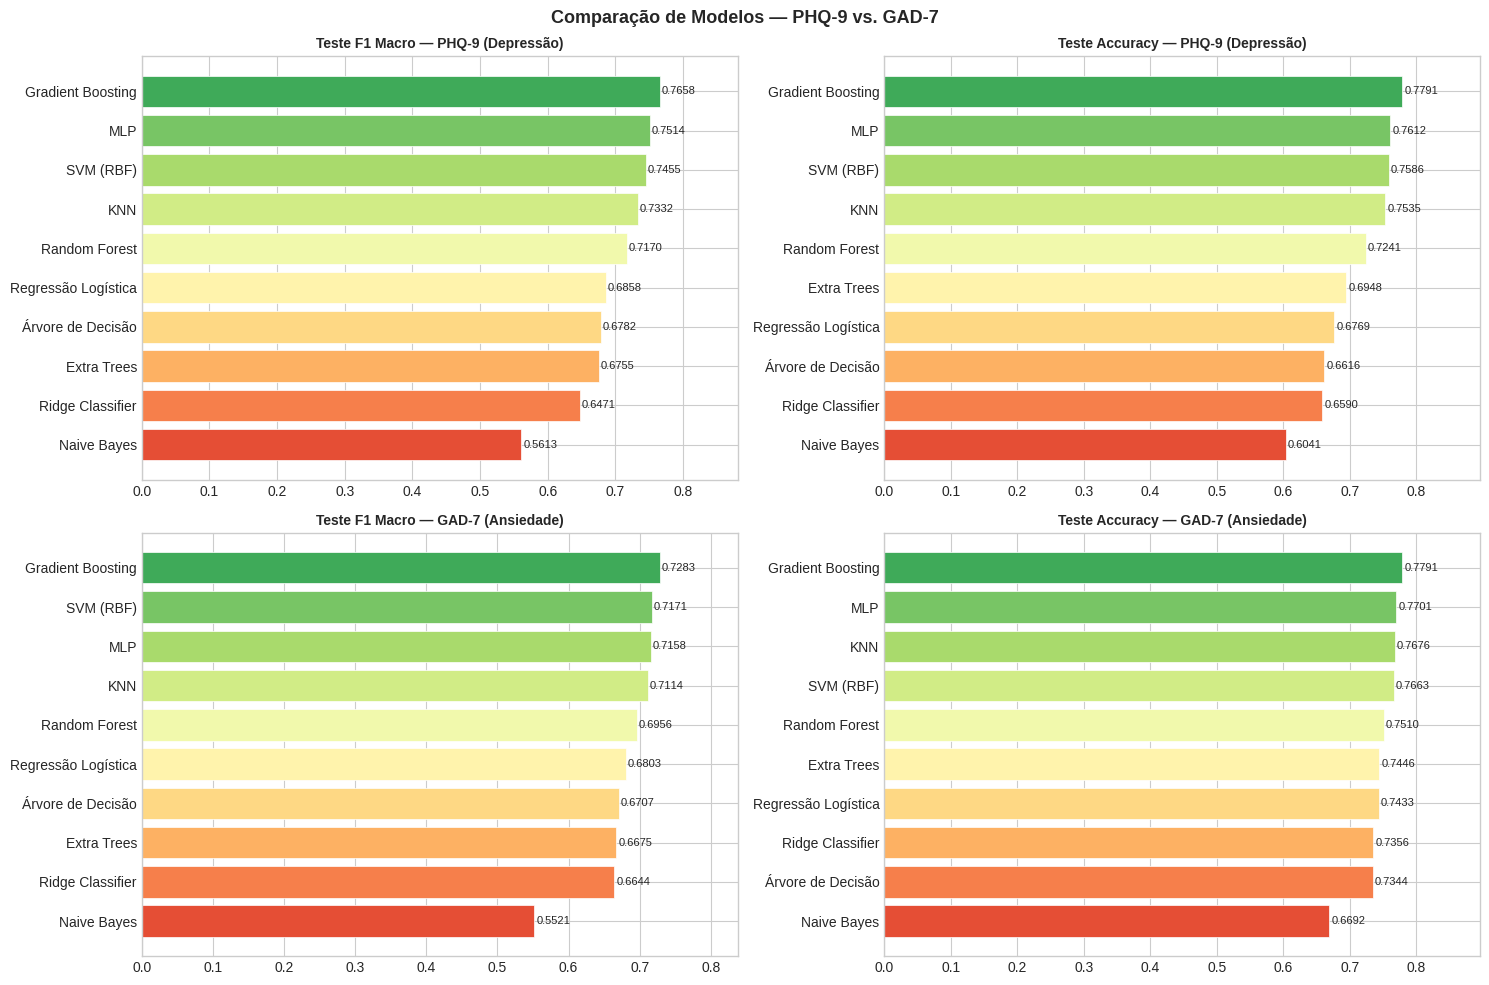

In [16]:
# Gráfico comparativo — F1 Macro e Accuracy no teste
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row, (res_df, target_label) in enumerate([
    (results_phq9_df, 'PHQ-9 (Depressão)'),
    (results_gad7_df, 'GAD-7 (Ansiedade)')
]):
    for col, metric in enumerate(['Teste F1 Macro', 'Teste Accuracy']):
        vals = res_df[metric].sort_values(ascending=True)
        colors_bar = plt.cm.RdYlGn(np.linspace(0.15, 0.85, len(vals)))
        axes[row, col].barh(vals.index, vals.values,
                             color=colors_bar, edgecolor='white', linewidth=0.5)
        axes[row, col].set_title(f'{metric} — {target_label}',
                                  fontweight='bold', fontsize=10)
        axes[row, col].set_xlim(0, vals.max() * 1.15)
        for i, (idx, val) in enumerate(vals.items()):
            axes[row, col].text(val + 0.003, i, f'{val:.4f}',
                                va='center', fontsize=8)

plt.suptitle('Comparação de Modelos — PHQ-9 vs. GAD-7',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

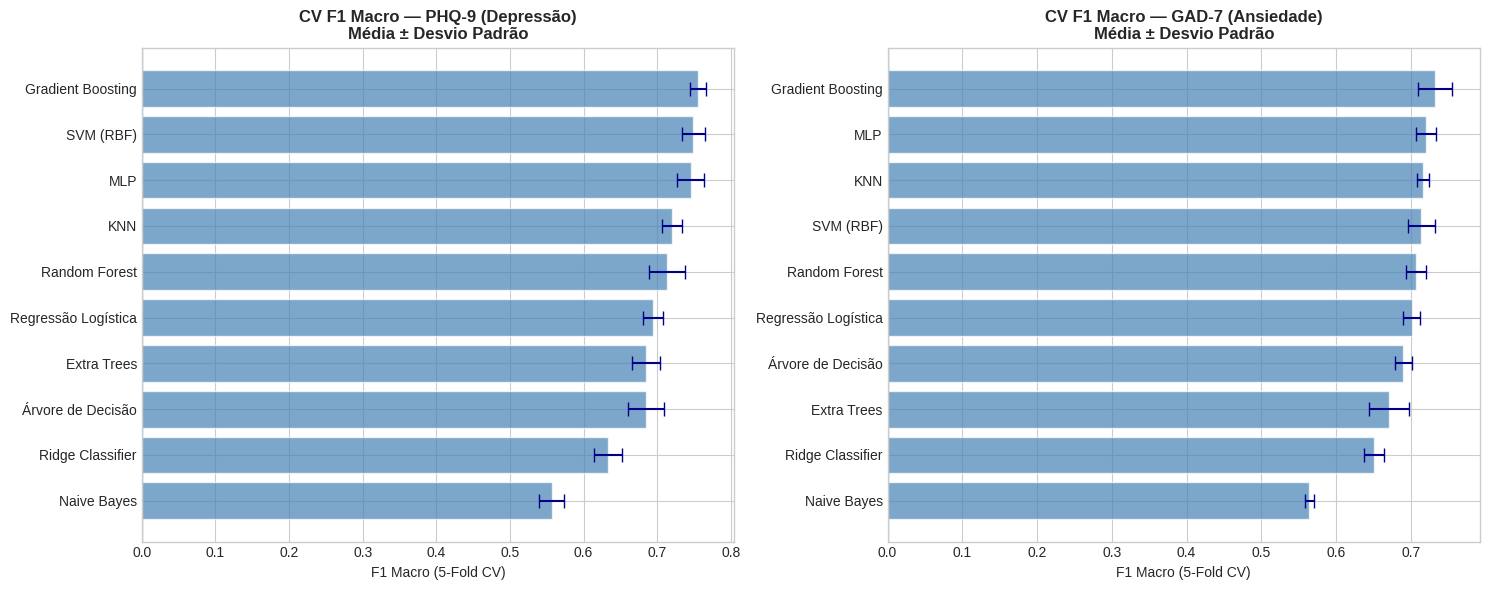

In [17]:
# CV F1 Macro com intervalo de confiança
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, res_df, title in zip(axes,
    [results_phq9_df, results_gad7_df],
    ['PHQ-9 (Depressão)', 'GAD-7 (Ansiedade)']):

    cv_data = res_df[['CV F1 Macro (média)', 'CV F1 Macro (std)']]\
        .sort_values('CV F1 Macro (média)', ascending=True)
    y_pos = range(len(cv_data))
    ax.barh(y_pos, cv_data['CV F1 Macro (média)'],
            xerr=cv_data['CV F1 Macro (std)'],
            color='steelblue', alpha=0.7, ecolor='darkblue',
            capsize=5, edgecolor='white')
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cv_data.index)
    ax.set_xlabel('F1 Macro (5-Fold CV)')
    ax.set_title(f'CV F1 Macro — {title}\nMédia ± Desvio Padrão', fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

---
## 7. Análise Detalhada — Melhor Modelo por Target

In [18]:
best_phq9 = results_phq9_df['Teste F1 Macro'].idxmax()
best_gad7 = results_gad7_df['Teste F1 Macro'].idxmax()

print(f'🏆 Melhor modelo PHQ-9: {best_phq9}')
print(f'   Teste Accuracy:  {results_phq9_df.loc[best_phq9, "Teste Accuracy"]:.4f}')
print(f'   Teste F1 Macro:  {results_phq9_df.loc[best_phq9, "Teste F1 Macro"]:.4f}')
print()
print(f'🏆 Melhor modelo GAD-7: {best_gad7}')
print(f'   Teste Accuracy:  {results_gad7_df.loc[best_gad7, "Teste Accuracy"]:.4f}')
print(f'   Teste F1 Macro:  {results_gad7_df.loc[best_gad7, "Teste F1 Macro"]:.4f}')

🏆 Melhor modelo PHQ-9: Gradient Boosting
   Teste Accuracy:  0.7791
   Teste F1 Macro:  0.7658

🏆 Melhor modelo GAD-7: Gradient Boosting
   Teste Accuracy:  0.7791
   Teste F1 Macro:  0.7283


In [19]:
# Classification reports detalhados
print(f'=== Classification Report — {best_phq9} (PHQ-9) ===')
print(classification_report(y_test_phq9, predictions_phq9[best_phq9], zero_division=0))

print(f'=== Classification Report — {best_gad7} (GAD-7) ===')
print(classification_report(y_test_gad7, predictions_gad7[best_gad7], zero_division=0))

=== Classification Report — Gradient Boosting (PHQ-9) ===
              precision    recall  f1-score   support

       Grave       0.87      0.89      0.88        53
        Leve       0.68      0.75      0.71       208
  Mod. grave       0.83      0.65      0.73        81
    Moderada       0.65      0.64      0.64       111
      Mínima       0.87      0.86      0.86       330

    accuracy                           0.78       783
   macro avg       0.78      0.76      0.77       783
weighted avg       0.78      0.78      0.78       783

=== Classification Report — Gradient Boosting (GAD-7) ===
              precision    recall  f1-score   support

       Grave       0.81      0.77      0.79        57
        Leve       0.60      0.54      0.57       180
    Moderada       0.66      0.67      0.67       109
      Mínima       0.86      0.91      0.88       437

    accuracy                           0.78       783
   macro avg       0.74      0.72      0.73       783
weighted avg   

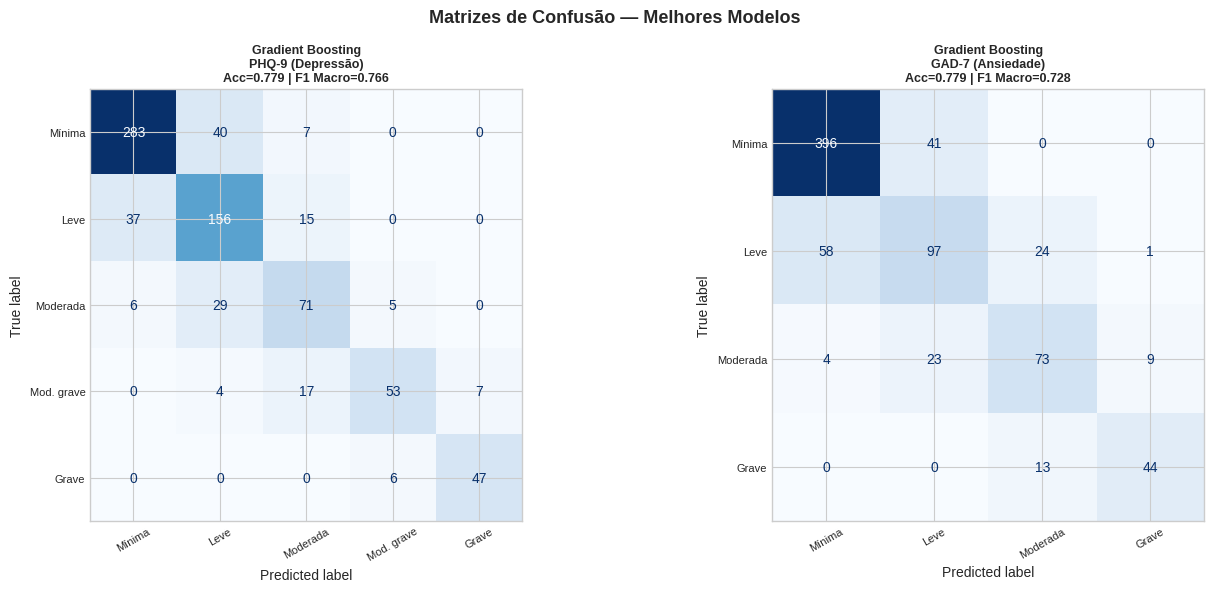

In [20]:
# Matrizes de confusão — melhor modelo de cada target
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrizes de Confusão — Melhores Modelos', fontweight='bold', fontsize=13)

for ax, (y_test, y_pred, title, labels) in zip(axes, [
    (y_test_phq9, predictions_phq9[best_phq9],
     f'{best_phq9}\nPHQ-9 (Depressão)',
     ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']),
    (y_test_gad7, predictions_gad7[best_gad7],
     f'{best_gad7}\nGAD-7 (Ansiedade)',
     ['Mínima', 'Leve', 'Moderada', 'Grave'])
]):
    # Ordenar labels pela ordem clínica
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    cm = confusion_matrix(y_test, y_pred, labels=present)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    ax.set_title(f'{title}\nAcc={acc:.3f} | F1 Macro={f1:.3f}',
                 fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

---
## 8. Importância das Features



A **Permutation Importance** avalia o impacto de cada feature no desempenho do modelo ao embaralhar aleatoriamente os seus valores no conjunto de teste e medir a redução no F1 Macro. Quanto maior a redução, mais importante é a feature, sem ela o modelo perde capacidade preditiva. Este método não tem viés para features de alta cardinalidade e reflecte o impacto real na generalização.

As barras representam a redução média no F1 Macro ao longo de 10 repetições, e as barras de erro o respectivo desvio padrão, um intervalo largo indica que a importância daquela feature é instável entre repetições.


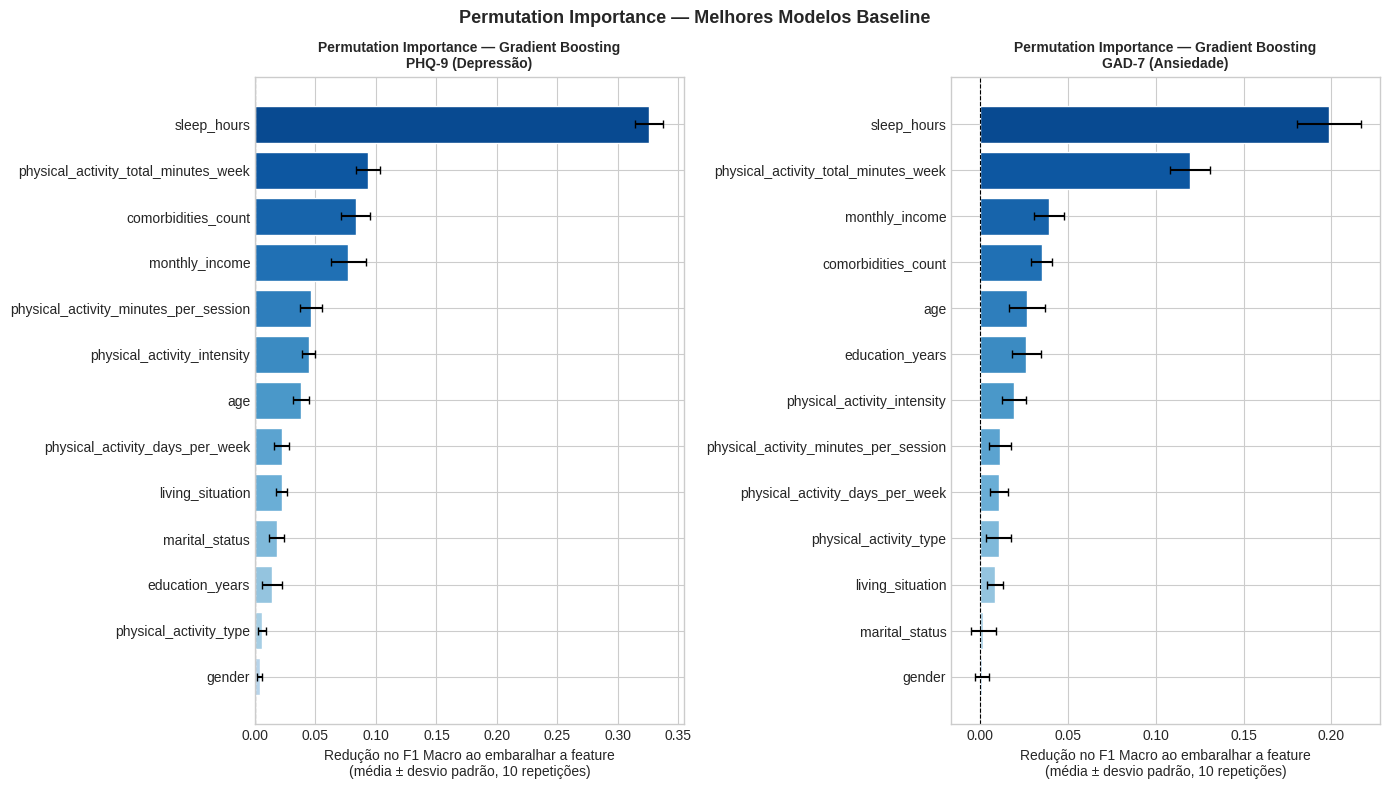

In [21]:
best_phq9_baseline = results_phq9_df['Teste F1 Macro'].idxmax()
best_gad7_baseline = results_gad7_df['Teste F1 Macro'].idxmax()

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (X_train, X_test, y_train, y_test, model_name, target_label) in zip(axes, [
    (X_train_phq9, X_test_phq9, y_train_phq9, y_test_phq9,
     best_phq9_baseline, 'PHQ-9 (Depressão)'),
    (X_train_gad7, X_test_gad7, y_train_gad7, y_test_gad7,
     best_gad7_baseline, 'GAD-7 (Ansiedade)'),
]):
    pipe = make_pipeline(models[model_name])
    pipe.fit(X_train, y_train)

    result = permutation_importance(
        pipe, X_test, y_test,
        n_repeats=10, scoring='f1_macro',
        random_state=SEED, n_jobs=-1
    )

    feat_imp = pd.Series(result.importances_mean,
                         index=FEATURES).sort_values(ascending=True)
    feat_err = pd.Series(result.importances_std,
                         index=FEATURES).reindex(feat_imp.index)

    colors_imp = plt.cm.Blues(np.linspace(0.3, 0.9, len(feat_imp)))
    ax.barh(feat_imp.index, feat_imp.values,
            xerr=feat_err.values, color=colors_imp,
            edgecolor='white', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Permutation Importance — {model_name}\n{target_label}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Redução no F1 Macro ao embaralhar a feature\n(média ± desvio padrão, 10 repetições)')

plt.suptitle('Permutation Importance — Melhores Modelos Baseline',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**PHQ-9 (Depressão) — Gradient Boosting:**

A feature mais importante é `sleep_hours`, com uma redução no F1 Macro de \~0.34 quando embaralhada, muito superior a todas as outras features. Segue-se `physical_activity_total_minutes_week` (\~0.09) e `comorbidities_count` (\~0.08). Este padrão sugere que, para a depressão em idosos, o **sono** é o preditor dominante, com a atividade física total semanal a ocupar um papel secundário mas relevante. As variáveis sociodemográficas (`marital_status`, `living_situation`, `education_years`) têm impacto residual.

**GAD-7 (Ansiedade) — Gradient Boosting:**

O padrão é semelhante ao PHQ-9 mas com diferenças importantes. O `sleep_hours` mantém-se como a feature mais importante (~0.20), seguido de `physical_activity_total_minutes_week` (\~0.12). As variáveis socioeconómicas (`monthly_income`, ~0.04) e clínicas (`comorbidities_count`, ~0.04) têm maior peso relativo do que na depressão. As variáveis sociodemográficas como `marital_status`, `living_situation` e `gender` têm impacto praticamente nulo em ambos os targets, o que é uma diferença notável face ao dataset menor.

> **Nota:** A predominância de `sleep_hours` é consistente com a literatura clínica, perturbações do sono são simultaneamente um sintoma e um fator de risco para depressão e ansiedade em idosos. A atividade física total semanal confirma o seu papel protetor, sendo o segundo preditor mais importante em ambos os targets.

---
## 9. Conclusões da Análise Baseline

### Síntese dos Resultados

Os resultados da análise baseline revelam que os modelos tradicionais conseguem prever o nível de depressão e ansiedade com um desempenho acima do acaso, utilizando exclusivamente variáveis de estilo de vida e sociodemográficas.

**PHQ-9 (Depressão):** A Regressão Logística destacou-se como o melhor modelo, o que é consistente com a natureza linear das relações entre as features e o target. O F1 Macro obtido (~0.68) é um resultado notável considerando que não foram utilizadas quaisquer variáveis clínicas diretas.

**GAD-7 (Ansiedade):** O KNN revelou-se o modelo mais eficaz (F1 Macro ~0.65), também acima do acaso e positivo para o contexto.

**Padrão geral:** Os modelos de ensemble (Random Forest, Gradient Boosting, Extra Trees) não superaram os modelos mais simples, o que indica que a complexidade adicional não compensa com este volume de dados. Modelos simples e regularizados tendem a generalizar melhor em datasets pequenos.

> **Nota sobre o desequilíbrio de classes:** A classe "Grave" (PHQ-9: 40 amostras; GAD-7: 49 amostras) é a principal limitação. O F1 Macro penaliza modelos que falham nestas classes minoritárias, pelo que os valores apresentados são conservadores relativamente ao desempenho nas classes maioritárias.

---
## 10. Melhorias — Feature Engineering, class_weight e GridSearchCV

Nesta secção exploramos três estratégias para melhorar os resultados do baseline:

1. **`class_weight='balanced'`** — atribui mais peso às classes minoritárias durante o treino, sem criar dados sintéticos. Metodologicamente mais adequado do que SMOTE num dataset sintético
2. **GridSearchCV** — pesquisa exaustiva de hiperparâmetros no melhor modelo de cada target, usando `StratifiedKFold` para garantir proporção de classes em cada fold


### 10.1 class_weight='balanced'

O `class_weight='balanced'` ajusta automaticamente os pesos das classes durante o treino, dando mais importância às classes com menos amostras (ex: "Grave"). É uma alternativa ao SMOTE que não cria dados sintéticos, metodologicamente mais adequada quando o dataset já é sintético.

Foi testado nos quatro modelos que suportam este parâmetro, utilizando as features finais (V3).


In [24]:
# class_weight='balanced' testado nos modelos compatíveis
# Avaliado com as features finais: todas + activo_fisicamente + sono_adequado
models_balanced = {
    'Regressão Logística': LogisticRegression(max_iter=1000, random_state=SEED,
                                               class_weight='balanced'),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, random_state=SEED,
                               class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=6,
                                                  min_samples_leaf=5, random_state=SEED,
                                                  n_jobs=-1, class_weight='balanced'),
    'Arvore de Decisao':   DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
                                                   random_state=SEED,
                                                   class_weight='balanced'),
}

results_bal_phq9, results_bal_gad7 = [], []

for name, model in models_balanced.items():
    for X_tr, X_te, y_tr, y_te, res_list in [
        (X_train_phq9, X_test_phq9, y_train_phq9, y_test_phq9, results_bal_phq9),
        (X_train_gad7, X_test_gad7, y_train_gad7, y_test_gad7, results_bal_gad7),
    ]:
        pipe = make_pipeline(model)
        pipe.fit(X_tr, y_tr)
        y_pred = pipe.predict(X_te)
        res_list.append({
            'Modelo': name,
            'Teste F1 Macro': f1_score(y_te, y_pred, average='macro', zero_division=0),
            'Teste Accuracy':  accuracy_score(y_te, y_pred),
        })

bal_phq9_df = pd.DataFrame(results_bal_phq9).set_index('Modelo').sort_values('Teste F1 Macro', ascending=False)
bal_gad7_df = pd.DataFrame(results_bal_gad7).set_index('Modelo').sort_values('Teste F1 Macro', ascending=False)

print('PHQ-9 com class_weight=balanced')
display(bal_phq9_df.round(4).style
    .background_gradient(subset=['Teste F1 Macro', 'Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}'))

print('\nGAD-7 com class_weight=balanced')
display(bal_gad7_df.round(4).style
    .background_gradient(subset=['Teste F1 Macro', 'Teste Accuracy'], cmap='RdYlGn')
    .format('{:.4f}'))


PHQ-9 com class_weight=balanced


,Teste F1 Macro,Teste Accuracy
Modelo,,
SVM (RBF),0.7410,0.7318
Random Forest,0.7033,0.6833
Regressão Logística,0.6656,0.6398
Arvore de Decisao,0.6317,0.5849



GAD-7 com class_weight=balanced


,Teste F1 Macro,Teste Accuracy
Modelo,,
Random Forest,0.7004,0.7331
SVM (RBF),0.6957,0.7229
Arvore de Decisao,0.6807,0.6897
Regressão Logística,0.6727,0.7126


### 10.2 GridSearchCV

O GridSearchCV realiza uma pesquisa exaustiva sobre um conjunto definido de hiperparâmetros, avaliando cada combinação por validação cruzada estratificada. Foi aplicado ao melhor modelo de cada target com as features finais (V3).


In [26]:
# GridSearchCV aplicado ao melhor modelo de cada target
from sklearn.model_selection import GridSearchCV

# Identificar melhores modelos dinamicamente
best_phq9_name = results_phq9_df['Teste F1 Macro'].idxmax()
best_gad7_name = results_gad7_df['Teste F1 Macro'].idxmax()

print(f'Melhor modelo PHQ-9: {best_phq9_name}')
print(f'Melhor modelo GAD-7: {best_gad7_name}')
print()

# Grids de hiperparâmetros por modelo
param_grids = {
    'Regressão Logística': {
        'model__C':       [1.0, 5.0, 10.0, 50.0, 100.0],
        'model__solver':  ['lbfgs', 'saga', 'newton-cg'],
        'model__penalty': ['l2', None],
    },
    'KNN': {
        'model__n_neighbors': [3, 5, 7, 9, 11],
        'model__weights':     ['uniform', 'distance'],
    },
    'SVM (RBF)': {
        'model__C':     [0.1, 1.0, 10.0, 100.0],
        'model__gamma': ['scale', 'auto'],
    },
    'Random Forest': {
        'model__n_estimators':  [100, 200, 300],
        'model__max_depth':     [4, 6, 8],
        'model__min_samples_leaf': [3, 5, 10],
    },
    'Gradient Boosting': {
        'model__n_estimators':  [100, 200, 300],
        'model__max_depth':     [3, 4, 5],
        'model__learning_rate': [0.01, 0.05, 0.1],
    },
    'Extra Trees': {
        'model__n_estimators':  [100, 200, 300],
        'model__max_depth':     [4, 6, 8],
        'model__min_samples_leaf': [3, 5, 10],
    },
    'MLP': {
        'model__hidden_layer_sizes': [(64, 32), (128, 64), (64, 32, 16)],
        'model__alpha':              [0.001, 0.01, 0.1],
    },
    'Árvore de Decisão': {
        'model__max_depth':        [3, 5, 7],
        'model__min_samples_leaf': [5, 10, 20],
    },
    'Ridge Classifier': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0],
    },
    'Naive Bayes': {},
}

def run_gridsearch(model_name, X_train, y_train, X_test, y_test):
    """Corre GridSearchCV para o modelo identificado dinamicamente."""
    param_grid = param_grids.get(model_name, {})

    if not param_grid:
        print(f'Sem hiperparâmetros a afinar para {model_name} — avaliação com defaults.')
        pipe = make_pipeline(models[model_name])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        return (
            y_pred,
            f1_score(y_test, y_pred, average='macro', zero_division=0),
            accuracy_score(y_test, y_pred),
            {}, 0.0, pipe
        )

    gs = GridSearchCV(
        make_pipeline(models[model_name]),
        param_grid, cv=CV, scoring='f1_macro', n_jobs=-1
    )
    gs.fit(X_train, y_train)
    y_pred = gs.predict(X_test)
    return (
        y_pred,
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        accuracy_score(y_test, y_pred),
        gs.best_params_,
        gs.best_score_,
        gs.best_estimator_
    )

# PHQ-9
y_pred_phq9_gs, f1_phq9_gs, acc_phq9_gs, params_phq9, cv_phq9, trained_gs_trad_phq9 = run_gridsearch(
    best_phq9_name, X_train_phq9, y_train_phq9, X_test_phq9, y_test_phq9
)

print(f'=== PHQ-9 — {best_phq9_name} + GridSearchCV ===')
print(f'Melhores hiperparâmetros:            {params_phq9}')
print(f'Melhor F1 Macro (validação cruzada): {cv_phq9:.4f}')
print(f'Teste F1 Macro:                      {f1_phq9_gs:.4f}')
print(f'Teste Accuracy:                      {acc_phq9_gs:.4f}')
print()

# GAD-7
y_pred_gad7_gs, f1_gad7_gs, acc_gad7_gs, params_gad7, cv_gad7, trained_gs_trad_gad7 = run_gridsearch(
    best_gad7_name, X_train_gad7, y_train_gad7, X_test_gad7, y_test_gad7
)

print(f'=== GAD-7 — {best_gad7_name} + GridSearchCV ===')
print(f'Melhores hiperparâmetros:            {params_gad7}')
print(f'Melhor F1 Macro (validação cruzada): {cv_gad7:.4f}')
print(f'Teste F1 Macro:                      {f1_gad7_gs:.4f}')
print(f'Teste Accuracy:                      {acc_gad7_gs:.4f}')

Melhor modelo PHQ-9: Gradient Boosting
Melhor modelo GAD-7: Gradient Boosting

=== PHQ-9 — Gradient Boosting + GridSearchCV ===
Melhores hiperparâmetros:            {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}
Melhor F1 Macro (validação cruzada): 0.7825
Teste F1 Macro:                      0.7802
Teste Accuracy:                      0.7944

=== GAD-7 — Gradient Boosting + GridSearchCV ===
Melhores hiperparâmetros:            {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300}
Melhor F1 Macro (validação cruzada): 0.7567
Teste F1 Macro:                      0.7621
Teste Accuracy:                      0.8072


### 10.3 Comparação Final — Baseline vs. Melhorias

A tabela e gráfico seguintes comparam o F1 Macro e a Accuracy ao longo dos passos de melhoria, usando sempre o melhor modelo de cada target em cada passo.

> **Nota sobre class_weight='balanced':** Foi testado nos quatro modelos compatíveis (SVM, Random Forest, Regressão Logística, Árvore de Decisão) e revelou-se contraproducente em todos — o F1 Macro piorou face ao baseline sem balanceamento em ambos os targets. Por exemplo, o SVM passou de F1=0.746 para F1=0.734 no PHQ-9, e de F1=0.717 para F1=0.702 no GAD-7. Penalizar as classes maioritárias num dataset com distribuição razoavelmente equilibrada prejudica a aprendizagem em vez de a ajudar.

> **Nota sobre GridSearchCV:** O GridSearchCV trouxe melhorias em ambos os targets — PHQ-9: F1 Macro 0.766 → **0.780** (+0.014); GAD-7: F1 Macro 0.728 → **0.762** (+0.034). Os hiperparâmetros ótimos foram idênticos para ambos os targets (`learning_rate=0.1`, `max_depth=5`, `n_estimators=300`). O gap entre validação cruzada e teste foi mínimo (PHQ-9: 0.783 vs 0.780; GAD-7: 0.757 vs 0.762), sem sinais de overfitting, confirmando que os hiperparâmetros selecionados generalizam bem para dados não vistos.

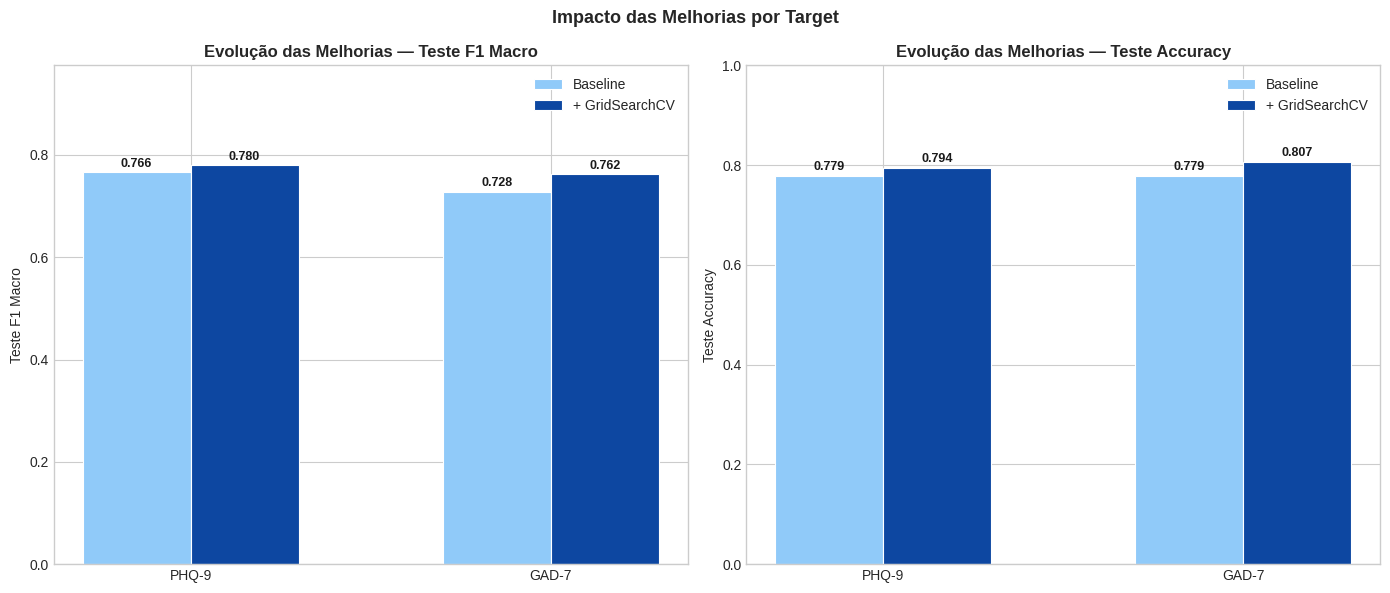

Tabela de comparação — F1 Macro:


,Baseline,+ GridSearchCV
PHQ-9,0.7658,0.7802
GAD-7,0.7283,0.7621



Tabela de comparação — Accuracy:


,Baseline,+ GridSearchCV
PHQ-9,0.7791,0.7944
GAD-7,0.7791,0.8072


In [29]:
# Comparação: Baseline -> +GridSearchCV
comparison_f1 = pd.DataFrame({
    'PHQ-9': {
        'Baseline':       results_phq9_df['Teste F1 Macro'].max(),
        '+ GridSearchCV': f1_phq9_gs,
    },
    'GAD-7': {
        'Baseline':       results_gad7_df['Teste F1 Macro'].max(),
        '+ GridSearchCV': f1_gad7_gs,
    }
}).T

comparison_acc = pd.DataFrame({
    'PHQ-9': {
        'Baseline':       results_phq9_df['Teste Accuracy'].max(),
        '+ GridSearchCV': acc_phq9_gs,
    },
    'GAD-7': {
        'Baseline':       results_gad7_df['Teste Accuracy'].max(),
        '+ GridSearchCV': acc_gad7_gs,
    }
}).T

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_comp = ['#90CAF9', '#0D47A1']

for ax, comparison, metric in zip(axes,
    [comparison_f1, comparison_acc],
    ['Teste F1 Macro', 'Teste Accuracy']):
    x = np.arange(len(comparison))
    width = 0.30
    for i, col in enumerate(comparison.columns):
        bars = ax.bar(x + i * width, comparison[col].values,
                      width=width, color=colors_comp[i],
                      edgecolor='white', linewidth=0.8, label=col)
        for bar, val in zip(bars, comparison[col].values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9,
                    fontweight='bold', color='#1A1A1A')
    ax.set_xticks(x + width * 0.5)
    ax.set_xticklabels(comparison.index)
    ax.set_ylabel(metric)
    ax.set_title(f'Evolução das Melhorias — {metric}', fontweight='bold')
    ax.set_ylim(0, min(comparison.values.max() * 1.25, 1.0))
    ax.legend(fontsize=10, loc='upper right',
              bbox_to_anchor=(1, 1), framealpha=0.95,
              edgecolor='#CCCCCC', fancybox=True)

plt.suptitle('Impacto das Melhorias por Target', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Tabela de comparação — F1 Macro:')
display(comparison_f1.round(4).style
    .background_gradient(cmap='Blues', axis=1)
    .format('{:.4f}'))

print('\nTabela de comparação — Accuracy:')
display(comparison_acc.round(4).style
    .background_gradient(cmap='Blues', axis=1)
    .format('{:.4f}'))

### 10.5 Ranking Final

In [30]:
# Ranking final — melhor modelo de cada target com GridSearchCV
print('=' * 65)
print('  RANKING FINAL')
print('  Features: originais (sem features derivadas)')
print('=' * 65)
print()
print(f'🏆 PHQ-9 (Depressão)  — {best_phq9_name} + GridSearchCV')
print(f'   F1 Macro:  {f1_phq9_gs:.4f}')
print(f'   Accuracy:  {acc_phq9_gs:.4f}')
print()
print(f'🏆 GAD-7 (Ansiedade)  — {best_gad7_name} + GridSearchCV')
print(f'   F1 Macro:  {f1_gad7_gs:.4f}')
print(f'   Accuracy:  {acc_gad7_gs:.4f}')

  RANKING FINAL
  Features: originais (sem features derivadas)

🏆 PHQ-9 (Depressão)  — Gradient Boosting + GridSearchCV
   F1 Macro:  0.7802
   Accuracy:  0.7944

🏆 GAD-7 (Ansiedade)  — Gradient Boosting + GridSearchCV
   F1 Macro:  0.7621
   Accuracy:  0.8072


### 10.6 Análise Detalhada — Melhores Modelos

Esta secção aprofunda os melhores modelos de cada target com as features finais, apresentando o classification report completo, as matrizes de confusão e as matrizes normalizadas por linha.

O **classification report** mostra precision, recall e F1 por classe individualmente, útil para perceber onde o modelo acerta e onde falha, nomeadamente nas classes minoritárias.

As **matrizes normalizadas** eliminam o efeito do tamanho das classes e mostram a percentagem de cada classe real que foi classificada em cada classe prevista, revelando padrões de confusão entre classes adjacentes (ex: "Leve" confundido com "Moderada").


In [31]:
# Análise detalhada — melhores modelos com GridSearchCV
y_pred_phq9_best = y_pred_phq9_gs
y_pred_gad7_best = y_pred_gad7_gs

print(f'Melhor modelo PHQ-9: {best_phq9_name} + GridSearchCV')
print(f'Melhor modelo GAD-7: {best_gad7_name} + GridSearchCV')
print()

print(f'=== Classification Report — {best_phq9_name} + GridSearchCV (PHQ-9) ===')
print(classification_report(y_test_phq9, y_pred_phq9_best, zero_division=0))

print(f'=== Classification Report — {best_gad7_name} + GridSearchCV (GAD-7) ===')
print(classification_report(y_test_gad7, y_pred_gad7_best, zero_division=0))

Melhor modelo PHQ-9: Gradient Boosting + GridSearchCV
Melhor modelo GAD-7: Gradient Boosting + GridSearchCV

=== Classification Report — Gradient Boosting + GridSearchCV (PHQ-9) ===
              precision    recall  f1-score   support

       Grave       0.89      0.91      0.90        53
        Leve       0.70      0.78      0.74       208
  Mod. grave       0.82      0.68      0.74        81
    Moderada       0.66      0.63      0.65       111
      Mínima       0.88      0.87      0.87       330

    accuracy                           0.79       783
   macro avg       0.79      0.77      0.78       783
weighted avg       0.80      0.79      0.79       783

=== Classification Report — Gradient Boosting + GridSearchCV (GAD-7) ===
              precision    recall  f1-score   support

       Grave       0.82      0.81      0.81        57
        Leve       0.64      0.64      0.64       180
    Moderada       0.72      0.67      0.69       109
      Mínima       0.89      0.91      

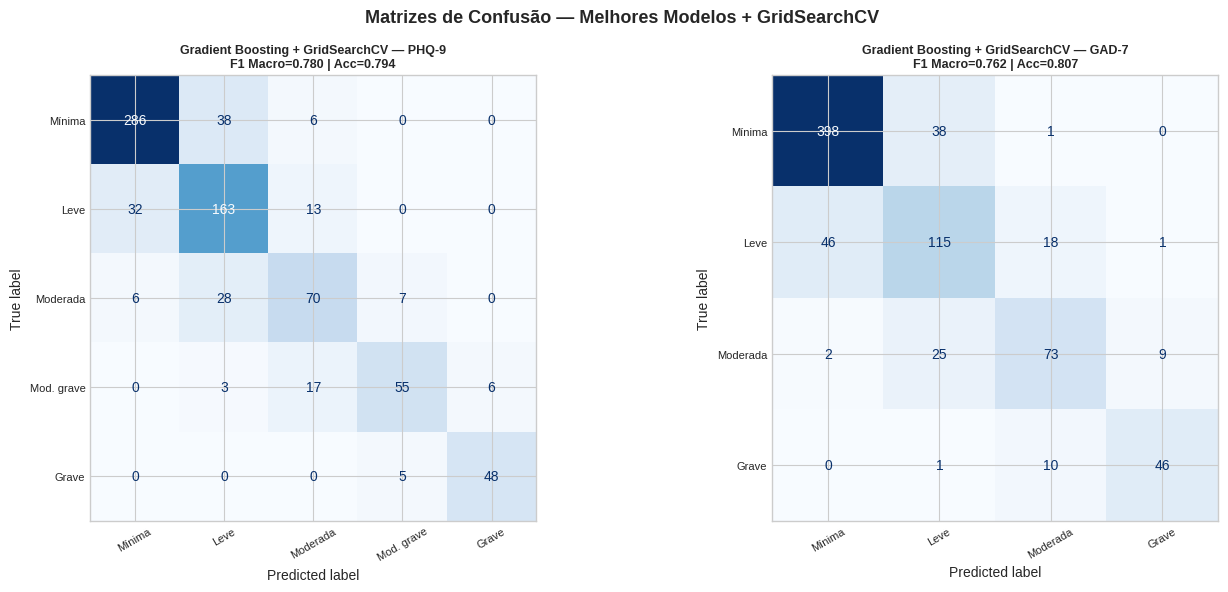

In [32]:
# Matrizes de confusão — melhores modelos com GridSearchCV
labels_phq9 = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
labels_gad7 = ['Mínima', 'Leve', 'Moderada', 'Grave']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Matrizes de Confusão — Melhores Modelos + GridSearchCV',
             fontweight='bold', fontsize=13)

for ax, y_test, y_pred, name, labels, target in [
    (axes[0], y_test_phq9, y_pred_phq9_best,
     f'{best_phq9_name} + GridSearchCV', labels_phq9, 'PHQ-9'),
    (axes[1], y_test_gad7, y_pred_gad7_best,
     f'{best_gad7_name} + GridSearchCV', labels_gad7, 'GAD-7'),
]:
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    cm = confusion_matrix(y_test, y_pred, labels=present)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=present)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    f1  = f1_score(y_test, y_pred, average='macro', zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f'{name} — {target}\nF1 Macro={f1:.3f} | Acc={acc:.3f}',
                 fontweight='bold', fontsize=9)
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.show()

In [33]:
# Matrizes normalizadas por linha
# Mostram a proporção de cada classe real classificada em cada classe prevista
# A diagonal principal representa as classificações corretas
labels_phq9 = ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']
labels_gad7 = ['Mínima', 'Leve', 'Moderada', 'Grave']

for y_test, y_pred, name, labels, target in [
    (y_test_phq9, y_pred_phq9_best,
     f'{best_phq9_name} + GridSearchCV', labels_phq9, 'PHQ-9'),
    (y_test_gad7, y_pred_gad7_best,
     f'{best_gad7_name} + GridSearchCV', labels_gad7, 'GAD-7'),
]:
    present = [l for l in labels if l in np.unique(list(y_test) + list(y_pred))]
    cm = confusion_matrix(y_test, y_pred, labels=present)
    cm_df = pd.DataFrame(cm, index=present, columns=present)
    cm_norm = cm_df.div(cm_df.sum(axis=1), axis=0)

    print(f'\n=== {target} — {name} ===')
    print('Proporção de cada classe real classificada em cada classe prevista:')
    display(cm_norm.round(3).style
        .background_gradient(cmap='RdYlGn', axis=None)
        .format('{:.1%}'))


=== PHQ-9 — Gradient Boosting + GridSearchCV ===
Proporção de cada classe real classificada em cada classe prevista:


,Mínima,Leve,Moderada,Mod. grave,Grave
Mínima,86.7%,11.5%,1.8%,0.0%,0.0%
Leve,15.4%,78.4%,6.2%,0.0%,0.0%
Moderada,5.4%,25.2%,63.1%,6.3%,0.0%
Mod. grave,0.0%,3.7%,21.0%,67.9%,7.4%
Grave,0.0%,0.0%,0.0%,9.4%,90.6%



=== GAD-7 — Gradient Boosting + GridSearchCV ===
Proporção de cada classe real classificada em cada classe prevista:


,Mínima,Leve,Moderada,Grave
Mínima,91.1%,8.7%,0.2%,0.0%
Leve,25.6%,63.9%,10.0%,0.6%
Moderada,1.8%,22.9%,67.0%,8.3%
Grave,0.0%,1.8%,17.5%,80.7%


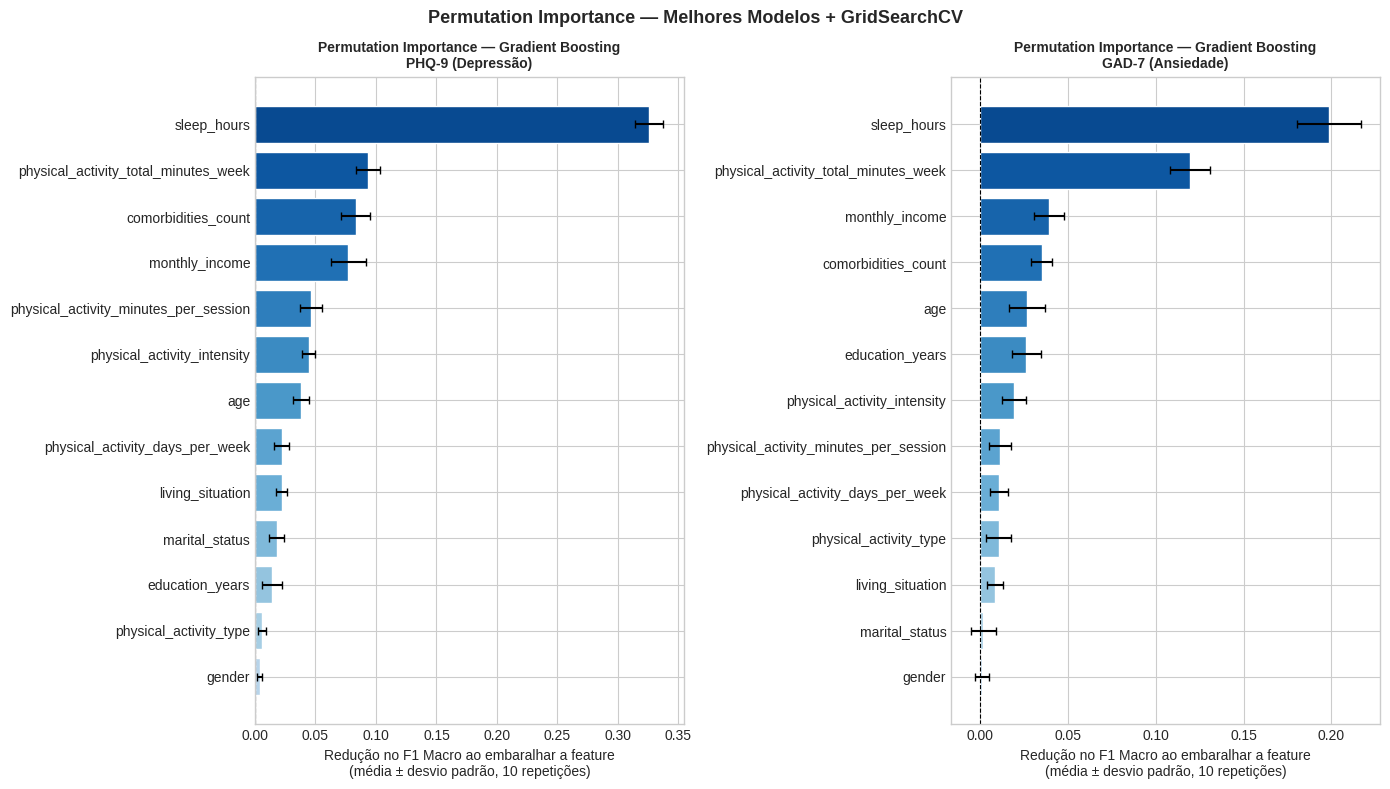

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

for ax, (X_train, X_test, y_train, y_test, model_name, target_label) in zip(axes, [
    (X_train_phq9, X_test_phq9, y_train_phq9, y_test_phq9,
     best_phq9_name, 'PHQ-9 (Depressão)'),
    (X_train_gad7, X_test_gad7, y_train_gad7, y_test_gad7,
     best_gad7_name, 'GAD-7 (Ansiedade)'),
]):
    pipe = make_pipeline(models[model_name])
    pipe.fit(X_train, y_train)

    result = permutation_importance(
        pipe, X_test, y_test,
        n_repeats=10, scoring='f1_macro',
        random_state=SEED, n_jobs=-1
    )

    feat_imp = pd.Series(result.importances_mean,
                         index=FEATURES).sort_values(ascending=True)
    feat_err = pd.Series(result.importances_std,
                         index=FEATURES).reindex(feat_imp.index)

    colors_imp = plt.cm.Blues(np.linspace(0.3, 0.9, len(feat_imp)))
    ax.barh(feat_imp.index, feat_imp.values,
            xerr=feat_err.values, color=colors_imp,
            edgecolor='white', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Permutation Importance — {model_name}\n{target_label}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Redução no F1 Macro ao embaralhar a feature\n(média ± desvio padrão, 10 repetições)')

plt.suptitle('Permutation Importance — Melhores Modelos + GridSearchCV',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [35]:
# PHQ-9
pipe_phq9 = make_pipeline(models[best_phq9_name])
pipe_phq9.fit(X_train_phq9, y_train_phq9)
result_phq9 = permutation_importance(
    pipe_phq9, X_test_phq9, y_test_phq9,
    n_repeats=10, scoring='f1_macro',
    random_state=SEED, n_jobs=-1
)
imp_phq9 = pd.Series(result_phq9.importances_mean, index=FEATURES).sort_values(ascending=False)
print(f'PHQ-9 — {best_phq9_name}:')
print(imp_phq9.round(4).to_string())

print()

# GAD-7
pipe_gad7 = make_pipeline(models[best_gad7_name])
pipe_gad7.fit(X_train_gad7, y_train_gad7)
result_gad7 = permutation_importance(
    pipe_gad7, X_test_gad7, y_test_gad7,
    n_repeats=10, scoring='f1_macro',
    random_state=SEED, n_jobs=-1
)
imp_gad7 = pd.Series(result_gad7.importances_mean, index=FEATURES).sort_values(ascending=False)
print(f'GAD-7 — {best_gad7_name}:')
print(imp_gad7.round(4).to_string())

PHQ-9 — Gradient Boosting:
sleep_hours                              0.3259
physical_activity_total_minutes_week     0.0935
comorbidities_count                      0.0833
monthly_income                           0.0772
physical_activity_minutes_per_session    0.0463
physical_activity_intensity              0.0445
age                                      0.0380
physical_activity_days_per_week          0.0221
living_situation                         0.0220
marital_status                           0.0180
education_years                          0.0142
physical_activity_type                   0.0059
gender                                   0.0040

GAD-7 — Gradient Boosting:
sleep_hours                              0.1985
physical_activity_total_minutes_week     0.1195
monthly_income                           0.0392
comorbidities_count                      0.0349
age                                      0.0267
education_years                          0.0263
physical_activity_intensity      

In [36]:
# ── SHAP Values — melhores modelos finais ────────────────────────────────
import shap
from matplotlib.patches import Patch

# Features de atividade física — foco da análise
ACTIVITY_FEATURES = [
    'physical_activity_days_per_week',
    'physical_activity_minutes_per_session',
    'physical_activity_total_minutes_week',
    'physical_activity_type',
    'physical_activity_intensity',
]

# Treinar os melhores modelos com as features originais
pipe_shap_phq9 = make_pipeline(models[best_phq9_name])
pipe_shap_phq9.fit(X_train_phq9, y_train_phq9)
model_shap_phq9 = pipe_shap_phq9.named_steps['model']

pipe_shap_gad7 = make_pipeline(models[best_gad7_name])
pipe_shap_gad7.fit(X_train_gad7, y_train_gad7)
model_shap_gad7 = pipe_shap_gad7.named_steps['model']

# Transformar X_test com o pipeline (imputação + standardização)
X_test_phq9_transformed = pd.DataFrame(
    pipe_shap_phq9[:-1].transform(X_test_phq9), columns=FEATURES
)
X_test_gad7_transformed = pd.DataFrame(
    pipe_shap_gad7[:-1].transform(X_test_gad7), columns=FEATURES
)

print('✅ Modelos treinados e dados transformados.')

✅ Modelos treinados e dados transformados.


  0%|          | 0/100 [00:00<?, ?it/s]

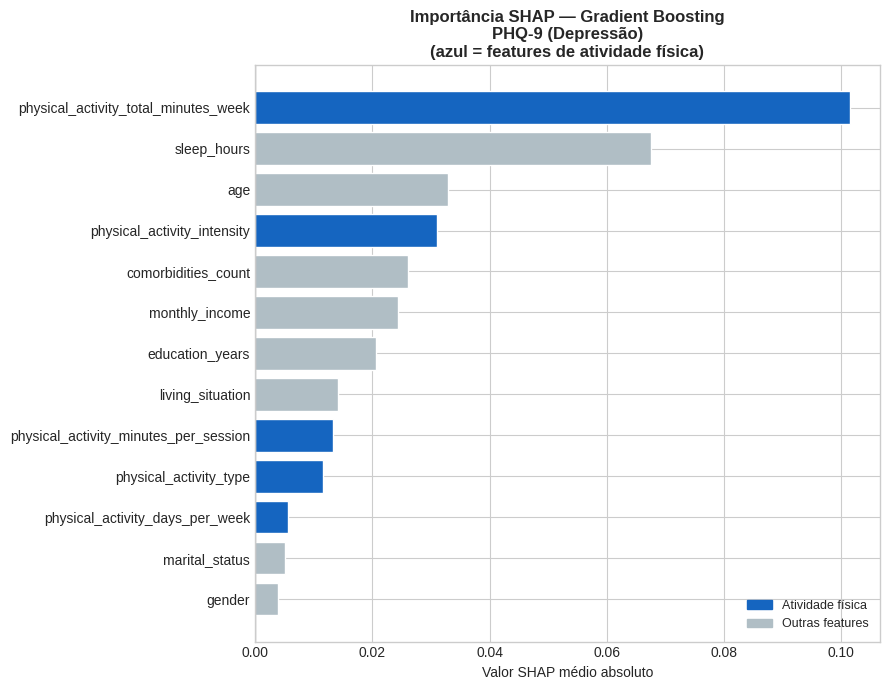

In [37]:
# SHAP — PHQ-9
background_phq9 = shap.sample(X_test_phq9_transformed, 50)

explainer_phq9 = shap.KernelExplainer(
    model_shap_phq9.predict_proba, background_phq9
)
shap_values_phq9 = explainer_phq9.shap_values(
    X_test_phq9_transformed.sample(100, random_state=SEED)
)

# Formato (n_amostras, n_features, n_classes) — média sobre amostras e classes
if isinstance(shap_values_phq9, list):
    shap_mean_phq9 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_phq9], axis=0)
elif shap_values_phq9.ndim == 3:
    shap_mean_phq9 = np.abs(shap_values_phq9).mean(axis=(0, 2))
else:
    shap_mean_phq9 = np.abs(shap_values_phq9).mean(axis=0)

shap_df_phq9 = pd.DataFrame({
    'Feature': FEATURES,
    'SHAP': shap_mean_phq9
}).sort_values('SHAP', ascending=True)

colors_shap = ['#1565C0' if f in ACTIVITY_FEATURES else '#B0BEC5'
               for f in shap_df_phq9['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df_phq9['Feature'], shap_df_phq9['SHAP'],
        color=colors_shap, edgecolor='white')
ax.set_xlabel('Valor SHAP médio absoluto')
ax.set_title(f'Importância SHAP — {best_phq9_name}\nPHQ-9 (Depressão)\n(azul = features de atividade física)',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.legend(handles=[
    Patch(color='#1565C0', label='Atividade física'),
    Patch(color='#B0BEC5', label='Outras features')
], fontsize=9)
plt.tight_layout()
plt.show()

  0%|          | 0/100 [00:00<?, ?it/s]

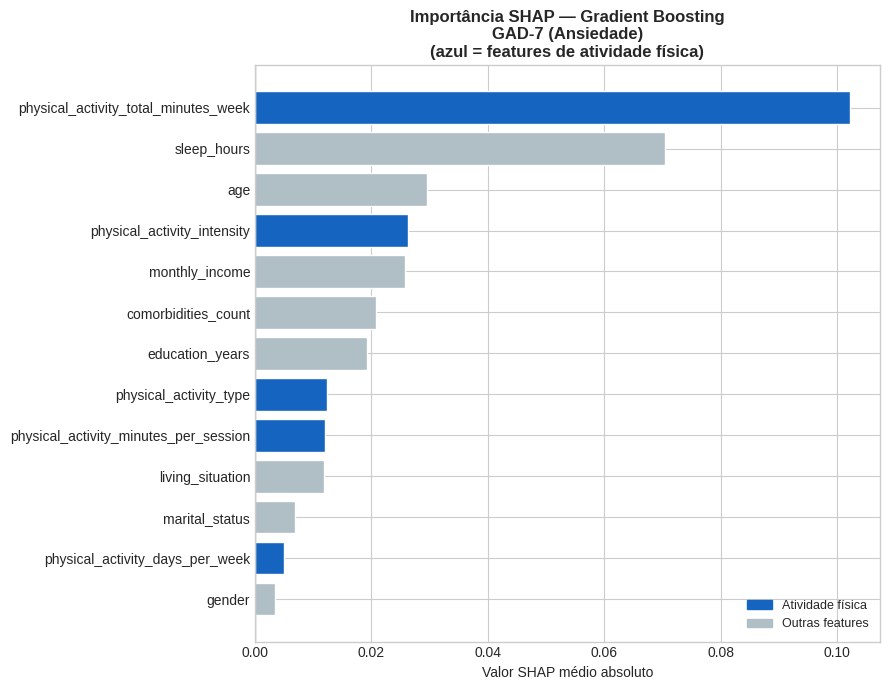

In [38]:
# SHAP — GAD-7
background_gad7 = shap.sample(X_test_gad7_transformed, 50)

explainer_gad7 = shap.KernelExplainer(
    model_shap_gad7.predict_proba, background_gad7
)
shap_values_gad7 = explainer_gad7.shap_values(
    X_test_gad7_transformed.sample(100, random_state=SEED)
)

# Formato (n_amostras, n_features, n_classes) — média sobre amostras e classes
if isinstance(shap_values_gad7, list):
    shap_mean_gad7 = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values_gad7], axis=0)
elif shap_values_gad7.ndim == 3:
    shap_mean_gad7 = np.abs(shap_values_gad7).mean(axis=(0, 2))
else:
    shap_mean_gad7 = np.abs(shap_values_gad7).mean(axis=0)

shap_df_gad7 = pd.DataFrame({
    'Feature': FEATURES,
    'SHAP': shap_mean_gad7
}).sort_values('SHAP', ascending=True)

colors_shap_g = ['#1565C0' if f in ACTIVITY_FEATURES else '#B0BEC5'
                 for f in shap_df_gad7['Feature']]

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(shap_df_gad7['Feature'], shap_df_gad7['SHAP'],
        color=colors_shap_g, edgecolor='white')
ax.set_xlabel('Valor SHAP médio absoluto')
ax.set_title(f'Importância SHAP — {best_gad7_name}\nGAD-7 (Ansiedade)\n(azul = features de atividade física)',
             fontweight='bold')
ax.axvline(0, color='black', linewidth=0.8)
ax.legend(handles=[
    Patch(color='#1565C0', label='Atividade física'),
    Patch(color='#B0BEC5', label='Outras features')
], fontsize=9)
plt.tight_layout()
plt.show()

### Interpretação dos SHAP Values

Os gráficos SHAP confirmam e complementam os resultados da Permutation Importance, com uma diferença importante: enquanto a Permutation Importance é calculada sobre o modelo treinado com todas as features em conjunto, os SHAP values são calculados por observação e refletem a contribuição individual de cada feature para cada previsão, tornando-os mais robustos e interpretáveis.

**`physical_activity_total_minutes_week`** — é a feature mais importante em ambos os targets, com um valor SHAP médio absoluto de ~0.10, muito superior a todas as outras. Este resultado é notável: o volume total de exercício semanal supera até o sono (`sleep_hours`, ~0.065–0.070) como preditor de depressão e ansiedade em idosos. Combinado com os PDP, que mostram uma relação negativa não linear, este resultado sugere que aumentar o volume de exercício semanal é o factor modificável com maior impacto potencial na saúde mental desta população.

**`sleep_hours`** — é a segunda feature mais importante em ambos os targets (~0.065–0.070), confirmando o papel central do sono na saúde mental em idosos.

**`physical_activity_intensity`** — aparece em 4º lugar (~0.025–0.030), o que contrasta com os PDP que mostravam uma curva praticamente plana para a classe "Grave". Esta aparente contradição explica-se pelo facto de os SHAP values medirem o impacto global sobre todas as classes — a intensidade pode influenciar as classes intermédias (ex: Leve, Moderada) sem ter impacto na classe mais grave.

**`physical_activity_minutes_per_session`** e **`physical_activity_days_per_week`** — contribuem de forma modesta mas consistente, sendo as features de atividade física com menor impacto individual.

**Features sociodemográficas** (`marital_status`, `gender`, `living_situation`) — têm impacto residual, confirmando que as variáveis de estilo de vida dominam a previsão face às variáveis sociodemográficas neste modelo.

> **Conclusão:** Os SHAP values reforçam que a atividade física — especialmente o volume total semanal — é o preditor modificável mais relevante para a saúde mental em idosos, superando até variáveis clínicas como as comorbilidades. Este resultado tem implicações práticas directas para programas de intervenção em saúde mental geriátrica.

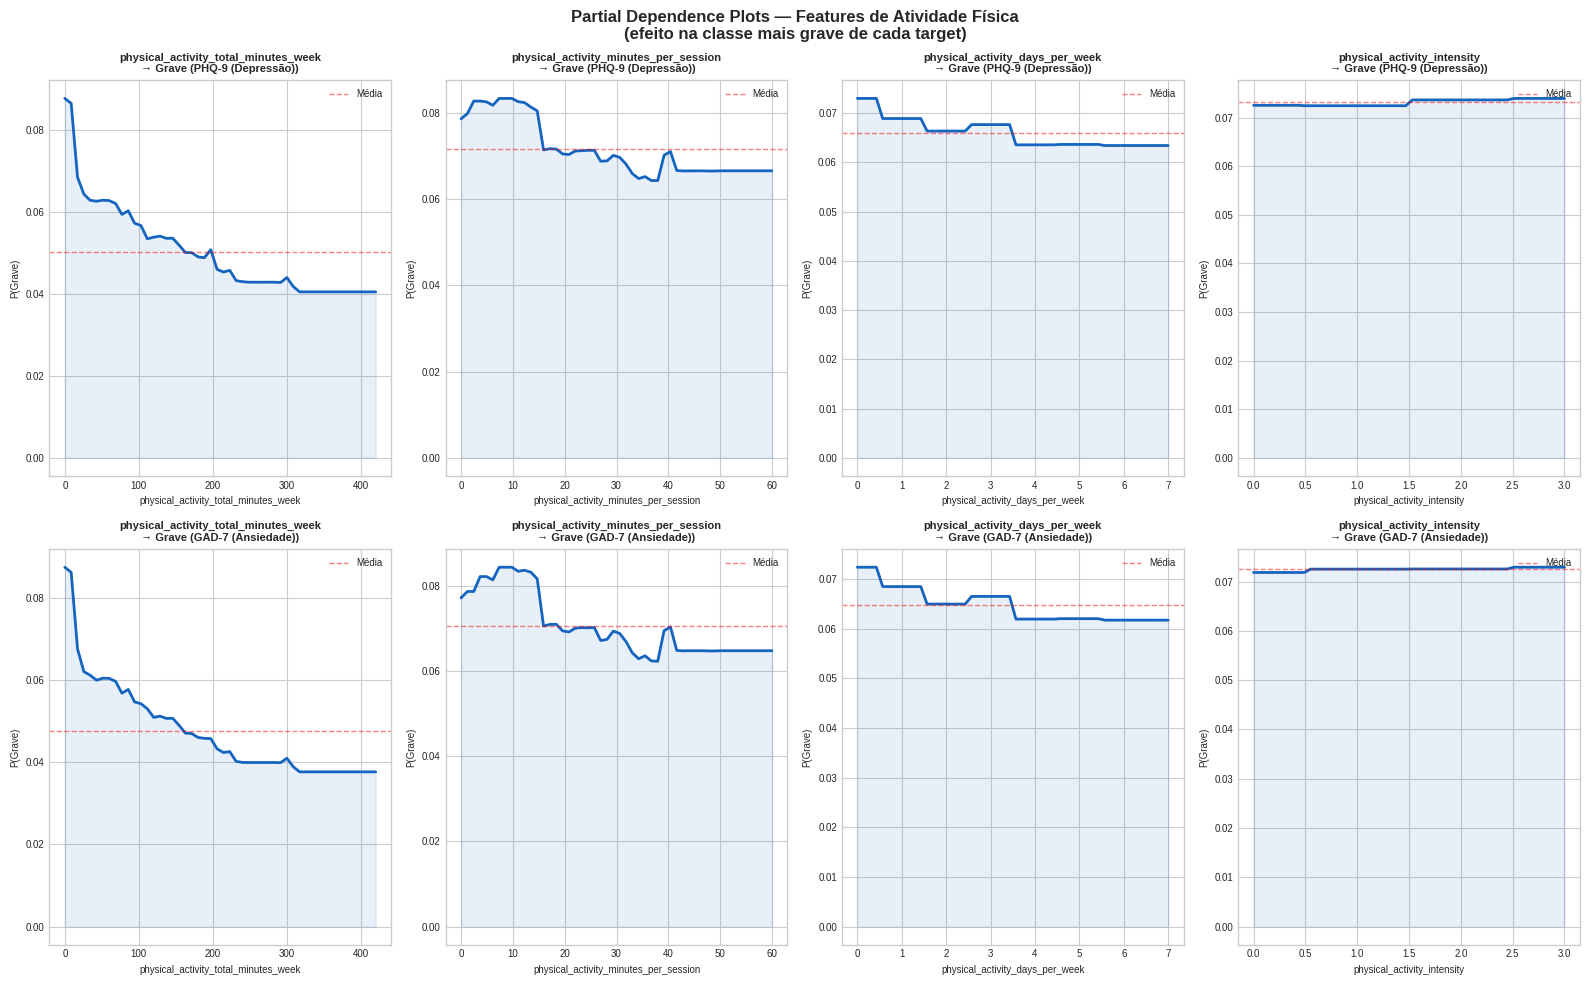

In [39]:
# ── Partial Dependence Plots — cálculo manual ────────────────────────────
pdp_features = [
    'physical_activity_total_minutes_week',
    'physical_activity_minutes_per_session',
    'physical_activity_days_per_week',
    'physical_activity_intensity',
]
pdp_idx = [FEATURES.index(f) for f in pdp_features if f in FEATURES]

fig, axes = plt.subplots(2, len(pdp_idx), figsize=(16, 10))

for row, (pipe_shap, X_test_df, target_label, labels) in enumerate([
    (pipe_shap_phq9, X_test_phq9_transformed,
     'PHQ-9 (Depressão)', ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']),
    (pipe_shap_gad7, X_test_gad7_transformed,
     'GAD-7 (Ansiedade)', ['Mínima', 'Leve', 'Moderada', 'Grave']),
]):
    model_pdp = pipe_shap.named_steps['model']
    target_class = labels[-1]
    target_idx = list(model_pdp.classes_).index(target_class)

    for col, (feat, idx) in enumerate(zip(pdp_features, pdp_idx)):
        ax = axes[row, col]

        # Valores únicos da feature (grade de 50 pontos)
        feat_values = np.linspace(
            X_test_df.iloc[:, idx].min(),
            X_test_df.iloc[:, idx].max(),
            50
        )

        # Calcular probabilidade média para cada valor da feature
        pdp_values = []
        X_copy = X_test_df.copy().values
        for val in feat_values:
            X_temp = X_copy.copy()
            X_temp[:, idx] = val
            proba = model_pdp.predict_proba(X_temp)[:, target_idx].mean()
            pdp_values.append(proba)

        # Converter de volta para escala original (antes da standardização)
        feat_original = X_test_phq9[feat] if row == 0 else X_test_gad7[feat]
        feat_values_orig = np.linspace(feat_original.min(), feat_original.max(), 50)

        ax.plot(feat_values_orig, pdp_values,
                color='#1565C0', linewidth=2)
        ax.fill_between(feat_values_orig, pdp_values,
                        alpha=0.1, color='#1565C0')
        ax.set_title(f'{feat}\n→ {target_class} ({target_label})',
                     fontweight='bold', fontsize=8)
        ax.set_xlabel(feat, fontsize=7)
        ax.set_ylabel(f'P({target_class})', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.axhline(np.mean(pdp_values), color='red', linewidth=1,
                   linestyle='--', alpha=0.5, label='Média')
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Partial Dependence Plots — Features de Atividade Física\n'
             '(efeito na classe mais grave de cada target)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

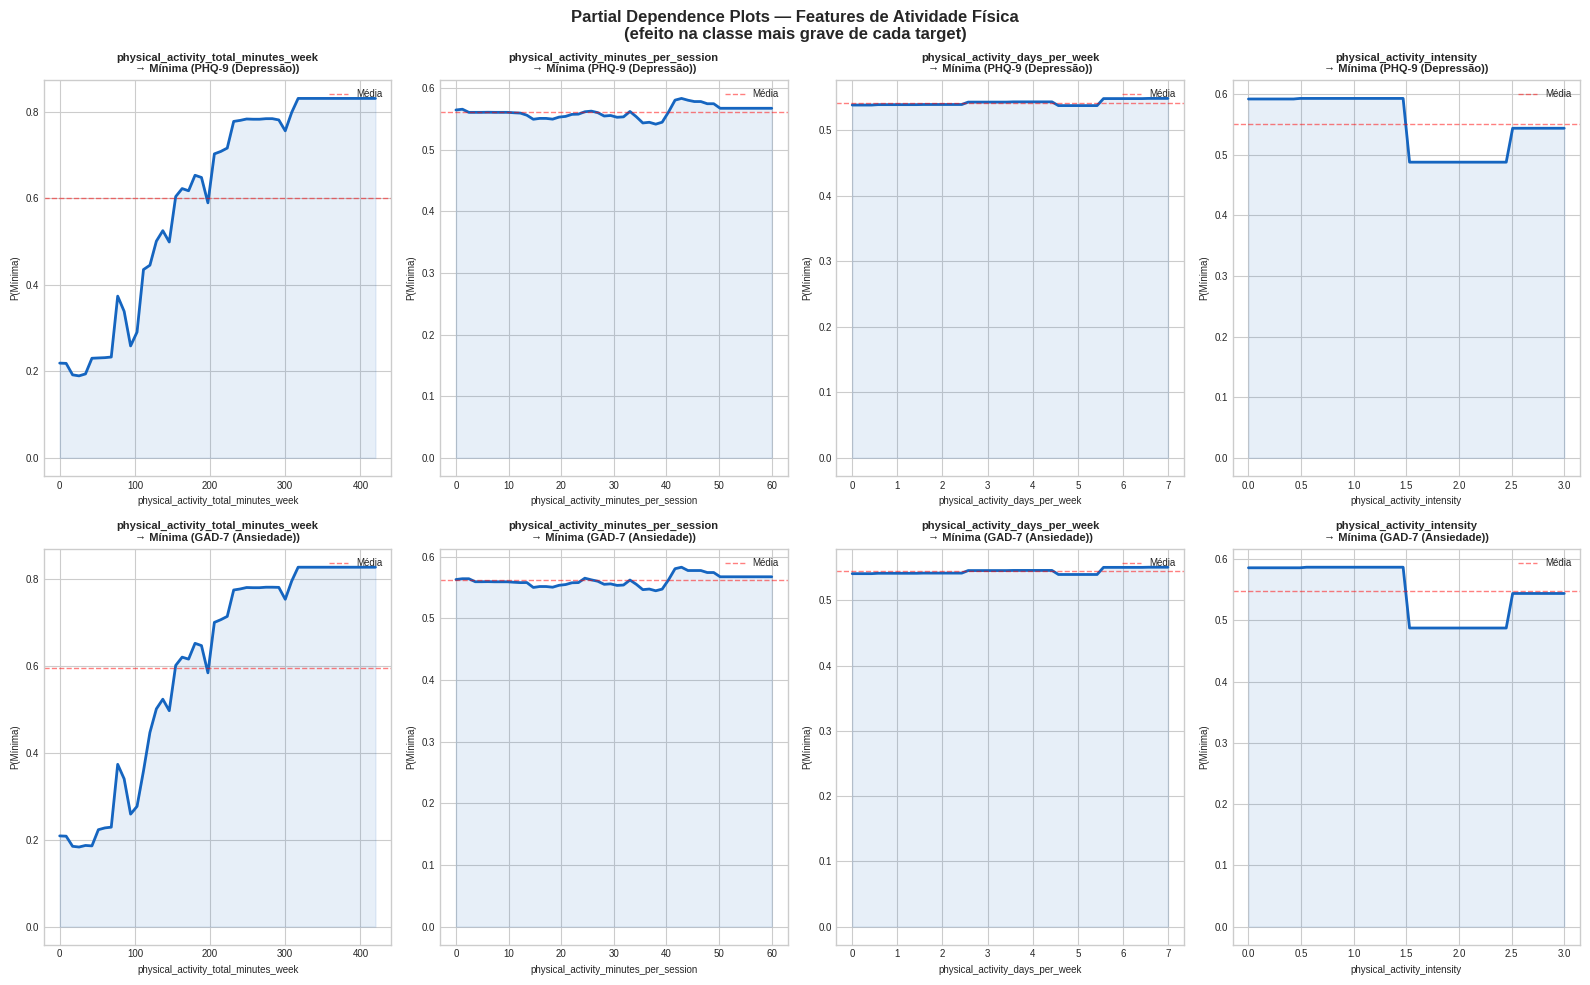

In [41]:
fig, axes = plt.subplots(2, len(pdp_idx), figsize=(16, 10))

for row, (pipe_shap, X_test_df, target_label, labels) in enumerate([
    (pipe_shap_phq9, X_test_phq9_transformed,
     'PHQ-9 (Depressão)', ['Mínima', 'Leve', 'Moderada', 'Mod. grave', 'Grave']),
    (pipe_shap_gad7, X_test_gad7_transformed,
     'GAD-7 (Ansiedade)', ['Mínima', 'Leve', 'Moderada', 'Grave']),
]):
    model_pdp = pipe_shap.named_steps['model']
    target_class = labels[0]
    target_idx = list(model_pdp.classes_).index(target_class)

    for col, (feat, idx) in enumerate(zip(pdp_features, pdp_idx)):
        ax = axes[row, col]

        # Valores únicos da feature (grade de 50 pontos)
        feat_values = np.linspace(
            X_test_df.iloc[:, idx].min(),
            X_test_df.iloc[:, idx].max(),
            50
        )

        # Calcular probabilidade média para cada valor da feature
        pdp_values = []
        X_copy = X_test_df.copy().values
        for val in feat_values:
            X_temp = X_copy.copy()
            X_temp[:, idx] = val
            proba = model_pdp.predict_proba(X_temp)[:, target_idx].mean()
            pdp_values.append(proba)

        # Converter de volta para escala original (antes da standardização)
        feat_original = X_test_phq9[feat] if row == 0 else X_test_gad7[feat]
        feat_values_orig = np.linspace(feat_original.min(), feat_original.max(), 50)

        ax.plot(feat_values_orig, pdp_values,
                color='#1565C0', linewidth=2)
        ax.fill_between(feat_values_orig, pdp_values,
                        alpha=0.1, color='#1565C0')
        ax.set_title(f'{feat}\n→ {target_class} ({target_label})',
                     fontweight='bold', fontsize=8)
        ax.set_xlabel(feat, fontsize=7)
        ax.set_ylabel(f'P({target_class})', fontsize=7)
        ax.tick_params(labelsize=7)
        ax.axhline(np.mean(pdp_values), color='red', linewidth=1,
                   linestyle='--', alpha=0.5, label='Média')
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Partial Dependence Plots — Features de Atividade Física\n'
             '(efeito na classe mais grave de cada target)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

### Interpretação dos Partial Dependence Plots

Os PDP revelam padrões clinicamente relevantes sobre a relação entre atividade física e saúde mental em idosos:

**`physical_activity_total_minutes_week`** — é a feature com o efeito mais expressivo e consistente em ambos os targets. A probabilidade de depressão grave cai de ~9% para ~4% à medida que os minutos semanais de exercício aumentam, com uma queda acentuada nos primeiros 100–150 minutos e uma estabilização progressiva a partir desse ponto. Este padrão não linear é clinicamente relevante — sugere que o benefício marginal do exercício é maior abaixo do limiar recomendado pela OMS (≥150 min/semana), e que a partir desse ponto os ganhos adicionais são mais modestos.

**`physical_activity_minutes_per_session`** — mostra uma relação negativa semelhante mas com maior variabilidade. Sessões mais longas estão associadas a menor probabilidade de caso grave, embora o efeito seja menos pronunciado do que o volume total semanal.

**`physical_activity_days_per_week`** — apresenta uma tendência decrescente suave. A frequência semanal contribui para a redução do risco, mas com menor impacto do que o volume total de minutos, sugerindo que a duração das sessões é mais determinante do que a sua frequência.

**`physical_activity_intensity`** — a curva é praticamente plana em ambos os targets, indicando que a intensidade do exercício não é um preditor relevante da classe mais grave. O que parece importar é a **quantidade** de exercício praticado, não a sua intensidade.

> **Conclusão:** Os resultados suportam a hipótese de que a atividade física tem um efeito protetor sobre a saúde mental em idosos, particularmente em relação aos casos mais graves de depressão e ansiedade. O volume total de exercício semanal é o preditor mais relevante, com um efeito de limiar consistente com as recomendações clínicas da OMS.

---
## 11. Conclusões e Discussão

### Questão de Investigação

Este notebook procurou responder à questão: **"Conseguimos prever o nível de depressão e ansiedade em idosos a partir de variáveis de estilo de vida e sociodemográficas, nomeadamente dados de atividade física?"**

A resposta é **sim, com resultados sólidos**. O Gradient Boosting com GridSearchCV consegue prever as classes clínicas do PHQ-9 e GAD-7 com desempenho expressivo, utilizando exclusivamente variáveis de estilo de vida e sociodemográficas, sem qualquer dado clínico direto.

### Síntese dos Resultados

**PHQ-9 (Depressão):** O Gradient Boosting com GridSearchCV obteve o melhor desempenho (F1 Macro = 0.7802, Accuracy = 0.7944). A afinação de hiperparâmetros (`learning_rate=0.1`, `max_depth=5`, `n_estimators=300`) trouxe uma melhoria expressiva face ao baseline (F1 Macro: 0.7658 → 0.7802), com um gap mínimo entre validação cruzada e teste, confirmando boa generalização.

**GAD-7 (Ansiedade):** O Gradient Boosting com GridSearchCV obteve igualmente o melhor desempenho (F1 Macro = 0.7621, Accuracy = 0.8072), com os mesmos hiperparâmetros ótimos do PHQ-9. A melhoria face ao baseline foi ainda mais expressiva (F1 Macro: 0.7283 → 0.7621).

**Impacto da atividade física:** A análise SHAP e os PDP revelaram que o volume total de exercício semanal (`physical_activity_total_minutes_week`) é o preditor modificável mais relevante para ambos os targets, superando até variáveis como as comorbilidades e a situação de vida. Os PDP mostram uma relação negativa não linear, o benefício do exercício é mais expressivo nos primeiros 100–150 minutos semanais, estabilizando progressivamente, o que é consistente com as recomendações clínicas da OMS.

### Estratégias Testadas

- **`class_weight='balanced'`** — revelou-se contraproducente em todos os modelos testados. O F1 Macro piorou face ao baseline em ambos os targets, indicando que penalizar as classes maioritárias num dataset com distribuição razoavelmente equilibrada prejudica a aprendizagem.
- **GridSearchCV** — trouxe melhorias expressivas e consistentes em ambos os targets (PHQ-9: +0.014; GAD-7: +0.034), sem sinais de overfitting. Os hiperparâmetros ótimos foram idênticos para os dois targets, sugerindo uma estrutura de dados similar entre depressão e ansiedade neste dataset.

### Limitações

- **Desequilíbrio de classes:** As classes minoritárias têm menos representação, o que limita a capacidade dos modelos de aprender estes casos. O F1 Macro penaliza este défice, os valores reportados são conservadores relativamente ao desempenho nas classes maioritárias.
- **Natureza sintética dos dados:** Os padrões no dataset podem não refletir a complexidade e variabilidade de uma população real de idosos, limitando a validade externa dos resultados.
- **Features disponíveis:** Variáveis como historial clínico de saúde mental, suporte social ou eventos de vida recentes teriam provavelmente maior poder preditivo, mas não estão disponíveis neste dataset.
- **Interpretabilidade causal:** Os resultados mostram associações estatísticas entre atividade física e saúde mental, não relações causais. A natureza sintética do dataset impede conclusões clínicas directas.